<a href="https://colab.research.google.com/github/xgpo-2226/TRACK_Topics_In_Machine_Learning/blob/FINAL-ASSEMENT/Grazia_OBUZOR_Khushi_MENON_Further_Research_Lab_Deep_reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STUDENT: **Grazia OBUZOR** ##

# <center> MDP, OpenAI Gym and DQN <center>
The goal of this notebook is to:
- Learn how to solve a simple MDP problem;
- show how to implement a DQN for a resource allocation problem.

If you want to know more about DQN, you can read:
- [Full gradient DQN reinforcement learning: A provably convergent scheme ](https://arxiv.org/pdf/2103.05981)
- Why DQN is bad: [Demystifying Approximate RL with epsilon-greedy Exploration: A Differential Inclusion View ](https://openreview.net/pdf?id=Ms1Zs8s7rg)

## Machine replacement
### Optimal policy
A machine has possible states in $\{1,\ldots,S\}$ that represent how good it performs (the higher the better), state 1 can be consider as broken, state S as new. At each instant $k=0,\ldots$ either the machine is replaced (action $a=1$) or it is left unchanged (action $a=2$). We assume that

\begin{equation}
\begin{array}{ll}
P(s_{k+1}=S|a_k=1) &=1\\
P(s_{k+1}=s|s_k=s\_ ,a_k=2) &=(1-\theta)\delta_{s\_ ,s}+\theta \delta_{\max(1,s\_-1 ),s}.
\end{array}
\end{equation}

where $\delta_{a,b}=1$ if $a=b$ and $0$ otherwise.

**1)** Explain the meaning of these probabilities.

**[ *Response 1*  ]** :

**The first probability, ($P(s_{k+1}=S|a_k=1) =1$) , signifies that if  the machine is replaced (action $a_k​=1$) at any given time, the machine's condition in the very next step ($s_{k+1}​$) can only be the state $S$ (essentially, with certainty). Since state $S$ represents a brand new machine, this simply means that replacing the old machine guarantees a new machine.**

**The second probability, $P(s_{k+1}​=s | s_k​=s\_,a_k=2)=(1− \theta)\delta_{s\_,s​}+\theta\delta_{max(1,s−1),s}$ , describes what happens when we decide to leave the machine unchanged (action $a_k​=2$). Here, $s$ is the current state and $s_{k+1}$ is the next state. With a probability of ($1−\theta$), the machine will remain in its current state ($s_{k+1}=s$), indicated by the term ($1−\theta$)$\delta_{s\_,s​}$​. However, incrementally, the machine's condition will worsen by one step, moving to state $s−1$, unless it is already in the worst state (state $1$), in which case it will remain in state $1$ - represented by the term $\theta\delta_{max(1,s−1),s}$. The value $\theta$ here represents the likelihood of the machine's condition degrading over time (given the current state) and if no action is taken.**
****

**2)** Give the expression of transition matrices $P(1)$ and $P(2)$ corresponding to actions $a_k=1$ and $a_k=2$.

**[ *Response 2*  ]** :

**The transition matrix P(1), corresponding to the action of replacing the machine ($a_k​=1$), is an $S×S$ matrix where every row has a $1$ in the column corresponding to state $S$ and $0$s in all other columns - reflecting the fact that regardless of the machine's current state, complete replacement always leads to a brand new machine (state $S$) with probability $1$.**

**The transition matrix $P(2)$, corresponding to the action of leaving the machine unchanged ($a_k​=2$), is also an $S×S$ matrix. The entry in the $s^{th}$ row and ${s_{k+1}}^{th}$ column, $P(2)_{s,s_{k+1}}$​, is given by $(1−\theta)\delta_{s_{k+1}},s​+ \theta\delta_{max(1,s−1),s_{k+1}}​$. This results in a matrix where for each state $s>1$, there is a probability of $1−\theta$ of staying in the same state $s$, and a probability of $\theta$ of transitioning to the next worse state $s−1$. For the worst state $s=1$, there is a probability of 1 of remaining in state 1. The matrix $P(2)$ will have values of $1−\theta$ on the main diagonal (except for the first element which is $1$), values of $\theta$ on the diagonal immediately below the main diagonal (except for the first row), and zeros elsewhere. ($\theta$ represents the machine's probability of degradation)**
****

At times $k=0,\ldots$, the cost of machine replacement is $c_k(s,a=1)=C$, while if the machine is not replaced, there is still a cost given by $c_k(s,a=2)=(S-s)/(S-1)$, due to the loss of quantity/quality of the production of the machine when its state degrades. The discouned cost is given by $\gamma^kc_k(s,a)$.

**3a)** Implement a functino *get_MDP(S,theta,C)* which returns P(1), P(2) and the R, the reward matrix, a Sx2 matrix having at each entry the reward of each state and action.

**[ *Response 3a*  ]** :

**Refer to functions to follow**

**3b)** Implement a function *simulation(s,a,S,P)* which simulates which state $s_{k+1}$ the machine will be at time $k+1$, knowing that the machine is in state $s_k=s$ and knowing that the operator decides to play $a_k=a$. P stocks P1 and P2, the model of the system. (Help: you have to realize that $s_{k+1}$ is drawn according to a multinomial of parameter $p(\cdot\mid s,a)$).

**[ *Response 3b*  ]** :

**Refer to functions to follow**

**3c)** Implement the trajectory of the MDP for a given policy $\pi$ in a function *trajectory(pi=$\pi$)* that outputs the trajectory of the state $s$, the trajectory of the action $a$, the resulting cumulative cost $J$ and the resulting discounted cumulative cost (Note: the cumulative cost is equal to the discounted cumulative cost when $\gamma=1$). You can assume the first state is $S$ with an initial cost $C$.

**[ *Response 3c*  ]** :

**Refer to functions to follow**

****

**4)** Implement a plotting function  *plot_trajectory(pi=$\pi$,policy='')* that runs the *trajectory* function for policy $\pi$ and plots the trajectories of $s$ and $a$ and gives the value of cumulative cost $J$. The policy string represents the legend in the plot.

**[ *Response 4*  ]** :

**Refer to functions to follow**

****

**5)** Express Bellman's value iteration algorithm. Implement the algorithm for $S=10$, $\theta=.5$, $C=100$ and discount factor $\gamma$ as a parameter.  

**[ *Response 5*  ]** :

**This value iteration equation is derived from the Bellman error equation and the optimal value function equation; it is then updated iteratively in the corresponding algorithm to find an optimal estimate for the state value function $𝑉^∗(𝑠)$ and the optimal policy $𝜋^∗(𝑠)$ for all states $𝑠 \in {1, . . . , 𝑆}$**

**$V^*(s)$ (or $\approx max_{a}Q(s, a)$) = $max_{a \in A} \{ R(s, a) + \gamma \Sigma_{s' ∈ S} P(s' | s, a) V^*(s') \}$**

/ - - /- - - / - - /- - - / - - /- - - / - - /- - -/ - - /- - - / - - /

**~ Start ~**

**Initialise**

**$𝑉(𝑠) = 0  \forall 𝑠 \in 𝑆$**


**Repeat until convergence:**

**For each state $𝑠 \in 𝑆$:**

- **For each action $ a \in \{1, 2\}$:**

 - **Compute:**
 $Q(s,a)=R(s,a)+ \gamma\Sigma P_{a}(s,s′)V(s′)$

- **Update value function:** $𝑉(𝑠) = max_{a}⁡𝑄(𝑠, 𝑎)$

- **Extract policy:** $\pi(s)=argmax_{a}Q(s,a)$

**Until convergence**  
**~ Return $V^*(s), \pi^*(s)$ ~  (Stop when the change in value ... $max_{𝑠}∣𝑉_{𝑘 + 1}(𝑠) − 𝑉_{𝑘}(𝑠)∣$ is below a threshold $\epsilon$ )**

****

**6)** For the optimal policy, plot a few trajectories of the MDP. Test the influence of parameters $\theta$, $C$, $\gamma$. In particular:

**6a)** Test for a small $\gamma$ (the future is very little taken into account) and different values of $C$. Describe the policy obtained for a small cost and for a large cost. Consider small \thetas (degradation is very fast) and large \theta (degradation is slow) What can you observe? Is the obtained policy consistent with your intuition?

**[ *Response 6a*  ]** :

**For a small discount factor ($\gamma = 0.01$) and a small replacement cost ($C = 0.1$), the optimal policy is to replace the machine whenever degradation occurs — as observed in the graphs, this is often when the machine reaches the state immediately below the best state ($S = 10 \rightarrow S=9$).
When the discount factor is small ($\gamma = 0.01$) and the replacement cost is large ($C = 100$), the optimal policy dictates replacing the machine only when it reaches the worst state ($S = 1$), despite the low discount factor, as the high replacement cost outweighs the immediate reward of replacement at lower states.
The parameter $\theta$ merely affects the rate of state degradation; a smaller $\theta$ (e.g., $\theta= 0.2$) results in the machine remaining in a given state for a higher number of iterations, while a larger $\theta$ (e.g., $\theta= 0.8$) leads to a steeper degradation gradient and increased oscillation between the "leave unchanged" (action 2) and "replace" (action 1) actions, particularly when the replacement cost is low.**


**6b)** Test for a large $\gamma<1$ (the future is taken into account to a large extent) and different values of $C$. Describe the policy obtained for a small cost and for a large cost. Consider again small $\theta$ (degradation is very fast) and large $\theta$ (degradation is slow) What can you observe? Is the obtained policy consistent with your intuition? What can you say with respect to **6a**?

**[ *Response 6b*  ]** :

**With a larger discount factor (e.g., $\gamma = 0.9$), the optimal policy places greater emphasis on future costs, leading to a higher value of replacing the machine earlier in its degradation cycle compared to the previous scenarios observed with a smaller discount factor. Essentially, with higher a discounted cost, early replacement of the machine is a better investment than in the case where discounted cost is negligable.**


------------

In [1]:
import numpy as np
import matplotlib.pyplot as plt

'''
Response 3a
'''

def get_MDP(S, theta, C, gamma):
  """
  Markov Decision Process to generate the transition matrices P(1), P(2) and the reward matrix R.

  Args:
    S: The number of states (integer).  # integer value to define the dimensions of the transition matrices
    theta: The probability of degradation (float between 0 and 1). # a probability, forcément 0-1
    C: The cost of replacement (float). at a time k, for which the machine is in state s, and takes an action a, e.g. how much to repair/completely replace the machine in the future given it current state and action taken
    gamma: The discount factor (float between 0 and 1).  # as defined in slide 3 of 35 powerpoint on MOODLE

  Returns:
    A tuple containing:
      - P1: The transition matrix for action a=1 (replacement) (NumPy array of shape (S, S)).
      - P2: The transition matrix for action a=2 (leave the machine unchanged) (NumPy array of shape (S, S)).
      - R: The reward matrix (NumPy array of shape (S, 2)). R[s-1, a-1] is the immediate reward
           obtained in state s when action a is taken. Since the problem defines costs, so function returns the negative of the costs as rewards.
  """
  # Initialize transition matrices
  P1 = np.zeros((S, S))
  P2 = np.zeros((S, S))

  # Transition matrix for action a = 1 (replacement)
  P1[:, S - 1] = 1  # Always goes to state S (new) for all rows in the very last column index

  # Transition matrix for action a = 2 (leave the machine unchanged)
  P2[0, 0] = 1  # If in state 1 (broken), stays in state 1 with certainty (probability of 1)
  for s in range(1, S):
    P2[s, s] = 1 - theta          # probability of staying in the current state
    P2[s, max(0, s - 1)] = theta  # probability of degrading to the next worse state

  # Reward matrix (negative of the costs)
  R = np.zeros((S, 2))

  # Cost for action a = 1 (replacement) is C
  for s in range(S):
    R[s, 0] = -C

  # Cost for action a = 2 (leave the machine unchanged) is (S - s) / (S - 1) as explained in the above question pretext
  if S > 1:
    for s in range(S):
      R[s, 1] = -(S - (s + 1)) / (S - 1)  # for each state in the reward column, the negative cost of arriving at that state is stored;
                                          # here s is used as an indexing counter, since indexing starts at 0 in python, but worst possible state is 1, must add an offset of 1: instead of - (S - s)
  elif S == 1:
    R[0, 1] = 0 # If only one state, no degradation cost; assume the machine will function infinitely

  return P1, P2, R

In [2]:
'''
Response 3b
'''
def simulation(s, a, S, P):
    """
    Simulates the next state given current state and action using transition probabilities.

    Args:
        s: Current state (integer, b-n 1 and S, 1-based indexing).
        a: Action taken (1 (replace) or 2 (leave machine unchanged)).
        S: Total number of states (integer, used indexing range of all possible states).
        P: Tuple containing transition matrices (P1, P2) from get_MDP().

    Returns:
        The next state (integer, b-n 1 and S, 1-based indexing).
    """
    P1, P2 = P    # from the get_MDP function's tuple output

    # Get transition probabilities for the chosen action, extracting all column values to make a 1D-array
    if a == 1:
        next_state = S  # necessarily means tha the next state needs to be the state rpresenting new, since a=1 (replacement)

    elif a == 2:
        probs = P2[s - 1, :]  # adjust for python 0 indexing

        # Sample next state from multinomial distribution
        next_state = np.random.choice(np.arange(1, S+1), p=probs)

    else:
      raise ValueError("Invalid action a")
      return('error')

    return next_state


In [3]:
'''
Response 3c
'''

def trajectory(pi, S, theta, C, gamma, max_steps=100):
    """
    Simulates a trajectory of the MDP under a given policy.

    Args:
        pi:  A policy function that takes the current state (s) and returns an action (a).
             # Therefore producing an int to int mapping from input to output:  `def pi(s: int) -> int`
        S:   The number of states.
        theta: Probability of degradation.
        C:   Cost of replacement.
        gamma: Discount factor  (0 <= gamma <= 1).
        max_steps: Maximum number/horizon (of trajectory) of steps to simulate (to prevent infinite loops). arbritrary default 100 chosen.

    Returns:
        A tuple containing:
            - states_traj:  List of states visited (1-based).
            - actions_traj: List of actions taken.
            - cumulative_cost: The total cost incurred.
            - discounted_cumulative_cost: The discounted cumalative cost.
    """

    P1, P2, R = get_MDP(S, theta, C, gamma)  # allows for function to be used without get_MDP needing to be used separately
    P = (P1, P2)  # Bundle transition matrices for simulation function
    s = S         # Start in state S (new)
    cost = 0
    discounted_cost = 0
    states_traj = [s]
    actions_traj = []

    for t in range(max_steps):  # Limit the trajectory length
        a = pi(s)
        actions_traj.append(a)
        cost += R[s - 1, a - 1]  # Add the cost (negative reward) already handled in get_MDS function
        discounted_cost += (gamma**t) * (R[s - 1, a - 1]) # ditto; dicounted cost factor included
        s = simulation(s, a, S, P)
        states_traj.append(s)

        if s == 1: # If the machine is broken, the simulation stops
          break


    return states_traj, actions_traj, cost, discounted_cost

In [4]:
'''
Response 4
'''

def plot_trajectory(pi, S, theta, C, gamma, policy_name="Policy"):
    """
    Runs the trajectory function for a given policy and plots the trajectories of states and actions over tiem,
    and gives the value of cumulative cost J.

    Args:
        pi:          The policy function.
        S:           Number of states.
        theta:       Degradation probability.
        C:           Replacement cost.
        gamma:       Discount factor.
        policy_name: Name of the policy for the plot legend.
    """

    states, actions, total_cost, discounted_total_cost = trajectory(pi, S, theta, C, gamma)

    # Create subplots
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot states
    axs[0].plot(states, label=f'States ({policy_name})', marker='o')
    axs[0].set_ylabel('State (s)')
    axs[0].set_title('Trajectory of States')
    axs[0].grid(True)
    axs[0].legend()

    # Plot actions
    axs[1].plot(actions, label=f'Actions ({policy_name})', marker='x', color='red')
    axs[1].set_xlabel('Time Step')
    axs[1].set_ylabel('Action (a)')
    axs[1].set_title('Trajectory of Actions')
    axs[1].set_yticks([1, 2])  # Assuming actions are 1 and 2
    axs[1].grid(True)
    axs[1].legend()

    # Display total cost
    plt.figtext(0.5, 0.01, f'Cumulative Cost (J): {total_cost:.2f}', ha='center', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for figtext
    plt.show()


if __name__ == '__main__':
    '''
    # Example usage:
    S = 5
    theta = 0.2
    C = 10
    gamma = 0.95 # suggested default values for testing by AI

    # Simple example policy (replace if state > 3, otherwise don't)
    def my_policy(s):
        return 1 if s <= 2 else 2 # replace if state is very degraded, just one state above complete breakdown
        # return 1 if s == 1 else 2  # replace if state is in broken state

    plot_trajectory(pi=my_policy, S=S, theta=theta, C=C, gamma=gamma, policy_name="Example Policy")
    '''

In [5]:
'''
Response 5 (Implementation Part)
'''

def value_iteration(gamma, S=10, theta=0.5, C=100, epsilon=1e-6):
    """
    Implements Bellman's Value Iteration algorithm.

    Args:
        S:       The number of states.
        theta:   Probability of degradation.
        C:       Cost of replacement.
        gamma:   Discount factor.               # first 4 inputs used to retrive matrices from get_MDP function
        epsilon: Convergence threshold.         # used in the stop condition (typical value used is miniscule e.g.1e-6)

        (could include max_iteration variable to avoid excissively long process, e.g.if num_iterations > 1000)

    Returns:
        V:       Optimal value function (NumPy array of shape (S,)).
        pi:      Optimal policy (NumPy array of shape (S,), where pi[s] is the optimal action (either 1-replace/2-leave) in state s).
        num_iterations: Number of iterations until convergence.
    """

    P1, P2, R = get_MDP(S, theta, C, gamma)
    P = (P1, P2)  # Bundle transition matrices

    # Initialization
    V = np.zeros(S)  # Initialize values to 0; improved per each iteration in the loop to follow
    num_iterations = 0

    # Iteration (infinitely, no limitting max_iterations for the loop)
    while True:
        V_new = np.zeros(S)
        pi = np.zeros(S, dtype=int)
        for s in range(S):
            # Bellman backup: find the best action
            q_values = []
            for a in [1, 2]:  # Actions are 1 (replace) and 2 (leave)
                if a == 1:
                    next_state_probs = P1[s, :]
                elif a == 2:
                    next_state_probs = P2[s, :]
                expected_value = np.sum(next_state_probs * V)          # can be obtained by dot product of next_state_probs and Value function
                q_values.append(R[s, a - 1] + gamma * expected_value)  # = Qs = [Q1, Q2]; a-1 for 0-based indexing
            V_new[s] = np.max(q_values)      # Extract best estimate of optimal value function
            pi[s] = np.argmax(q_values) + 1  # Extract best estimate of optimal policy; +1 to get 1-based action (1/2 not 0/2)

        # Convergence Check
        if np.max(np.abs(V_new - V)) < epsilon:
            print(f"Converged in {num_iterations+1} iterations.")
            num_iterations += 1
            break

        V = V_new             # extract best estimate for value function for each iteration
        num_iterations += 1

    return V, pi, num_iterations


if __name__ == '__main__':

    '''
    # Example applicaiton (default values given in question 5)
    # S = 5      # with 8+ states (at Cost = (-)10), 1 or more states will suggest doing nothing even if machine's state degrades
    # theta = 0.2
    # C = 10
    gamma = 0.95  # as suggested before

    # Run Value Iteration
    V_optimal, pi_optimal, iterations = value_iteration(gamma)

    # Print results
    print("Optimal Value Function:")
    print(V_optimal)
    print("\nOptimal Policy:")
    print(pi_optimal)
    print("\nNumber of Iterations:", iterations)

    '''



--- Small Gamma (gamma= 0.01 ) ---

--- Small Cost (C= 0.1 ) ---
Converged in 4 iterations.


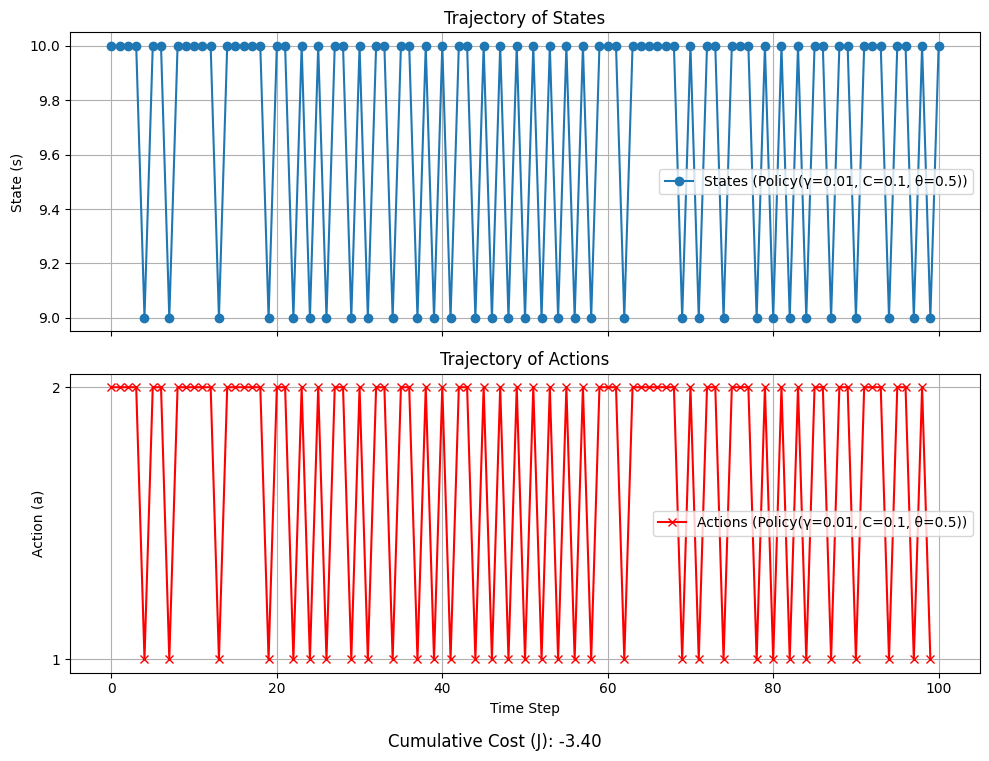

Converged in 4 iterations.


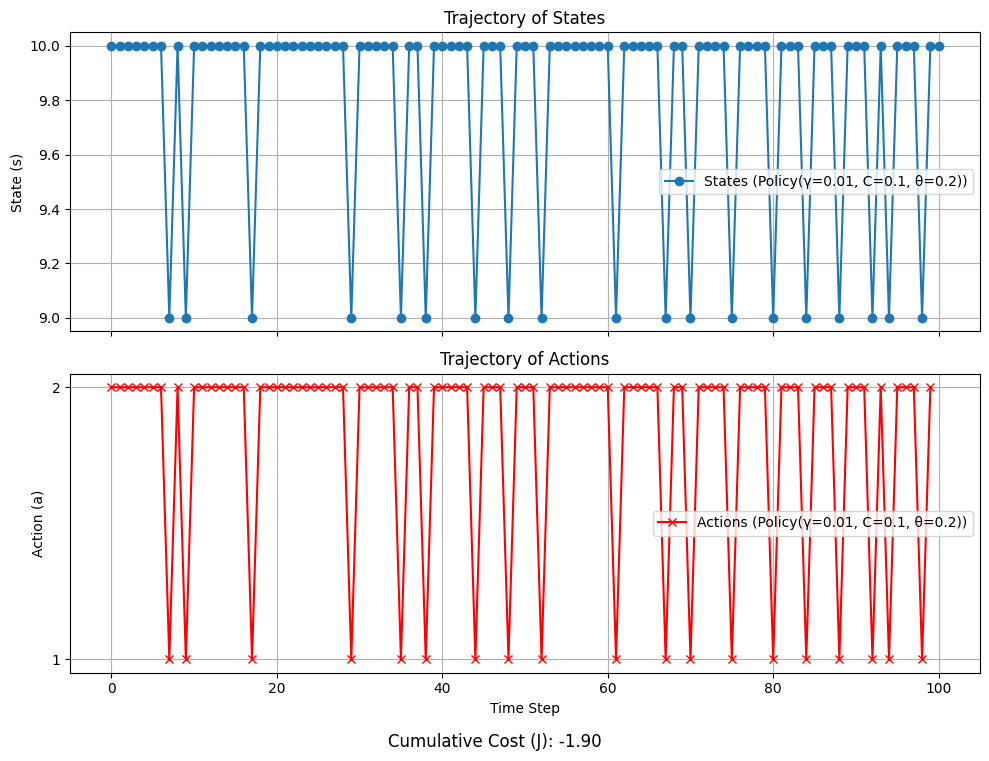

Converged in 4 iterations.


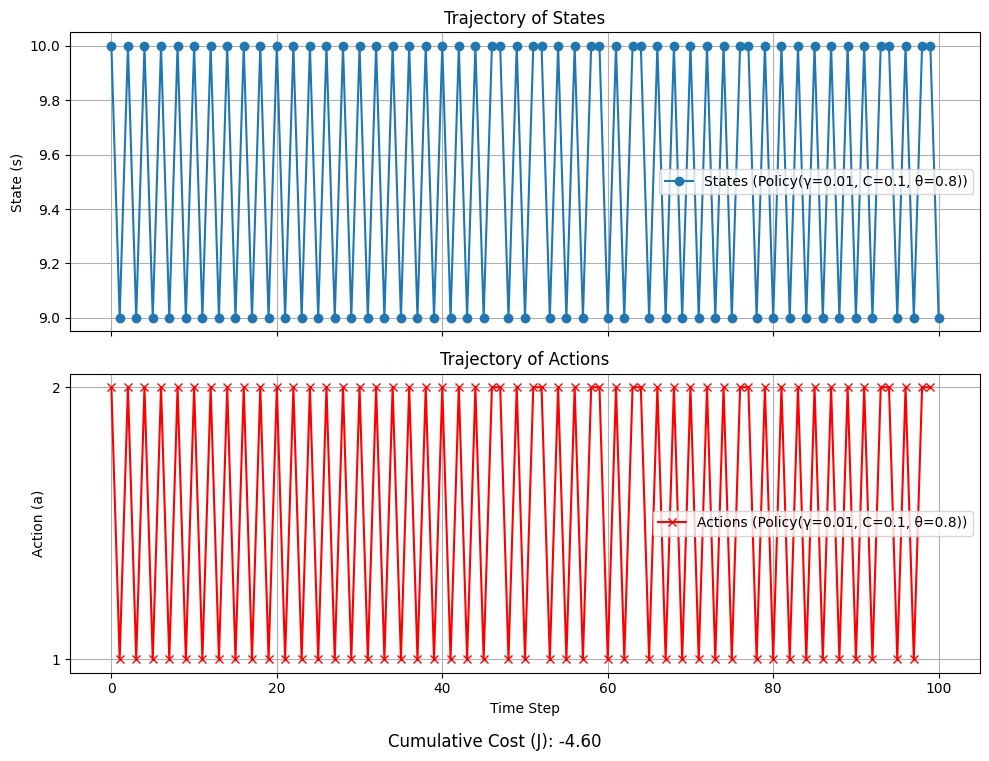


--- Mid Cost (C= 0.5 ) ---
Converged in 4 iterations.


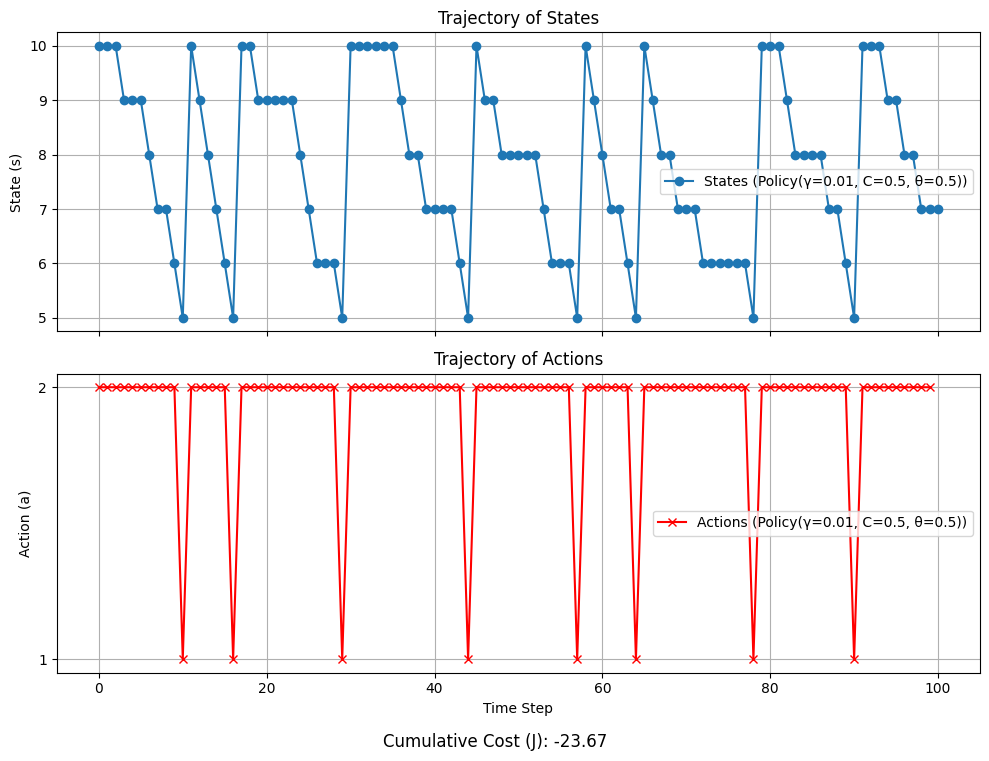

Converged in 4 iterations.


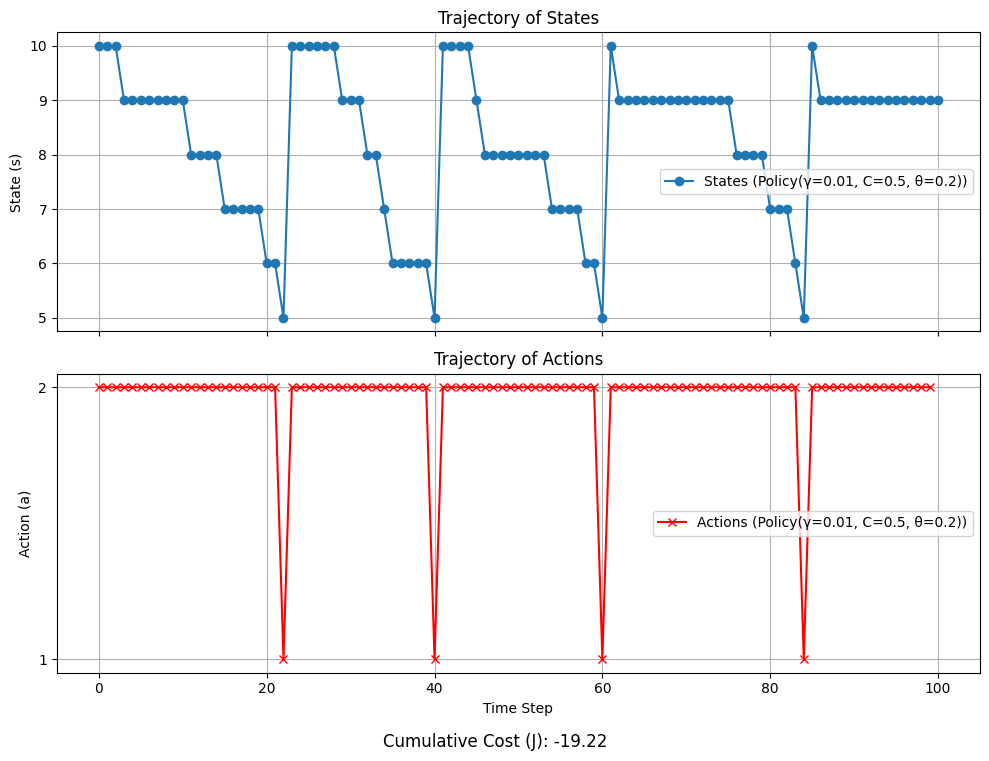

Converged in 4 iterations.


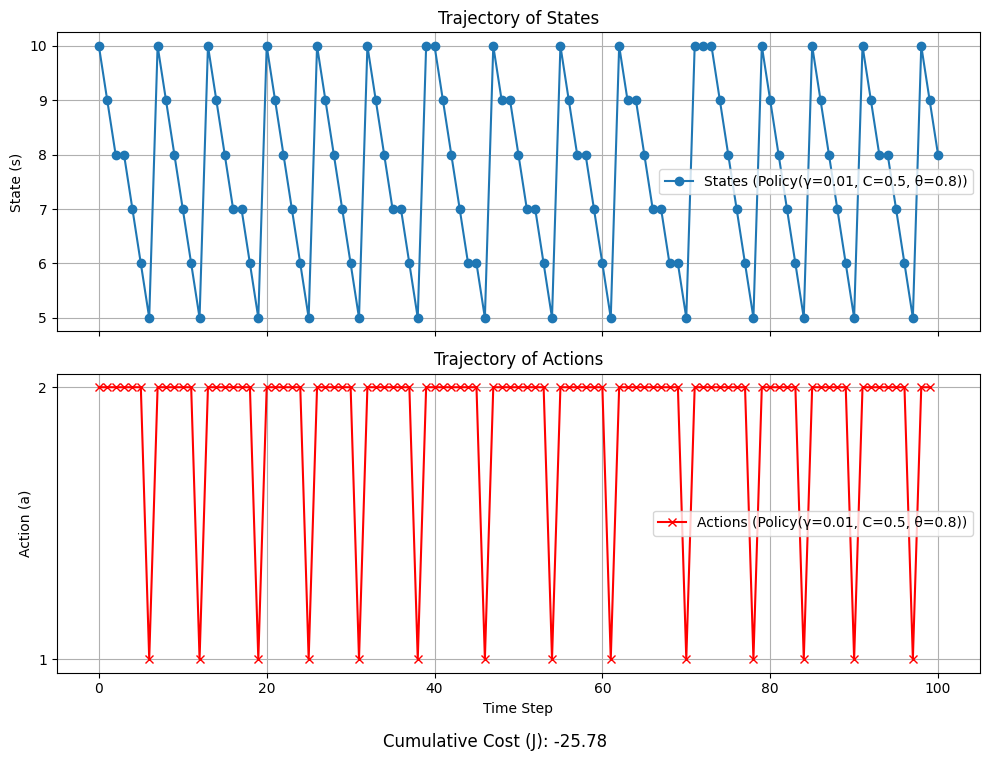


--- Large Cost (C= 100 ) ---
Converged in 4 iterations.


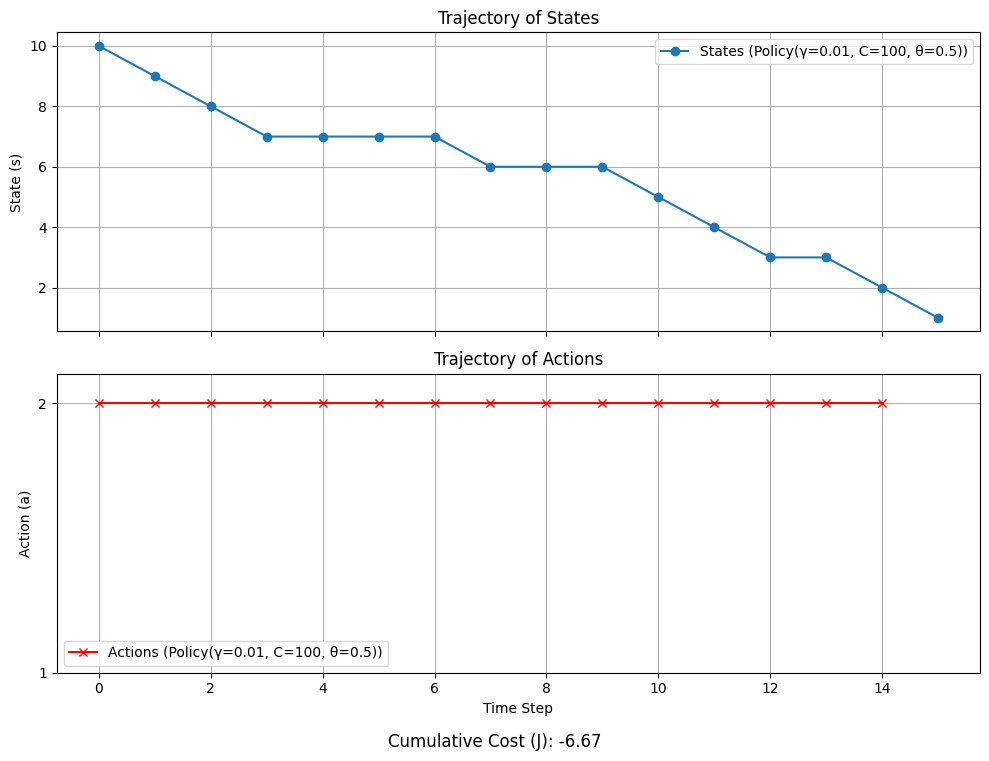

Converged in 4 iterations.


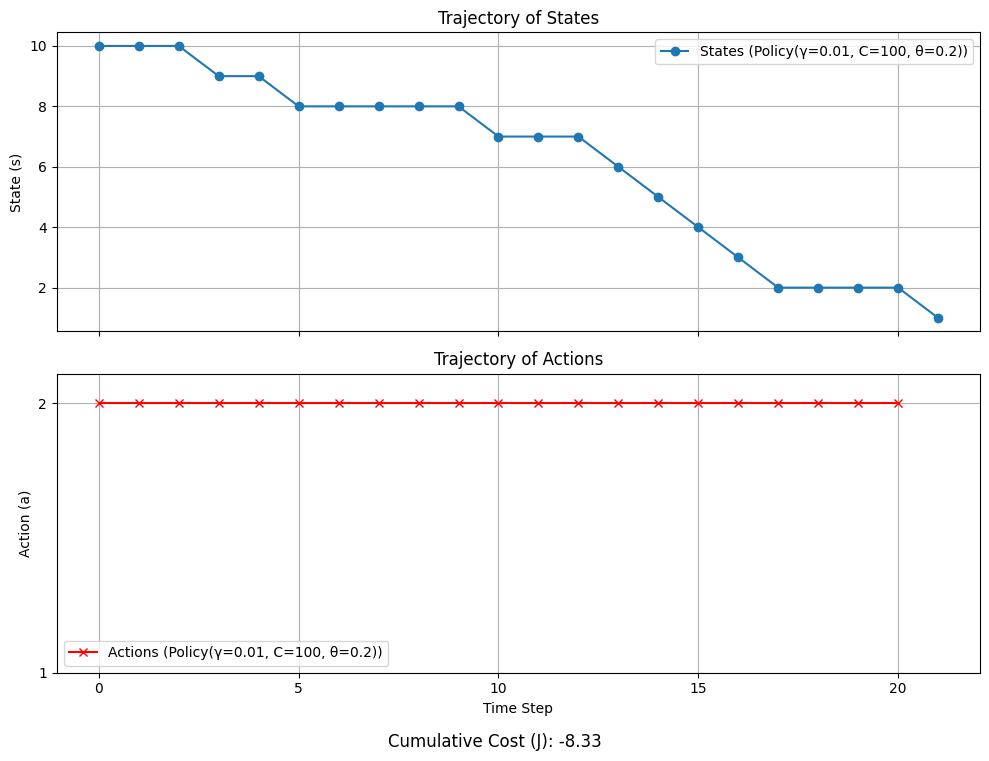

Converged in 4 iterations.


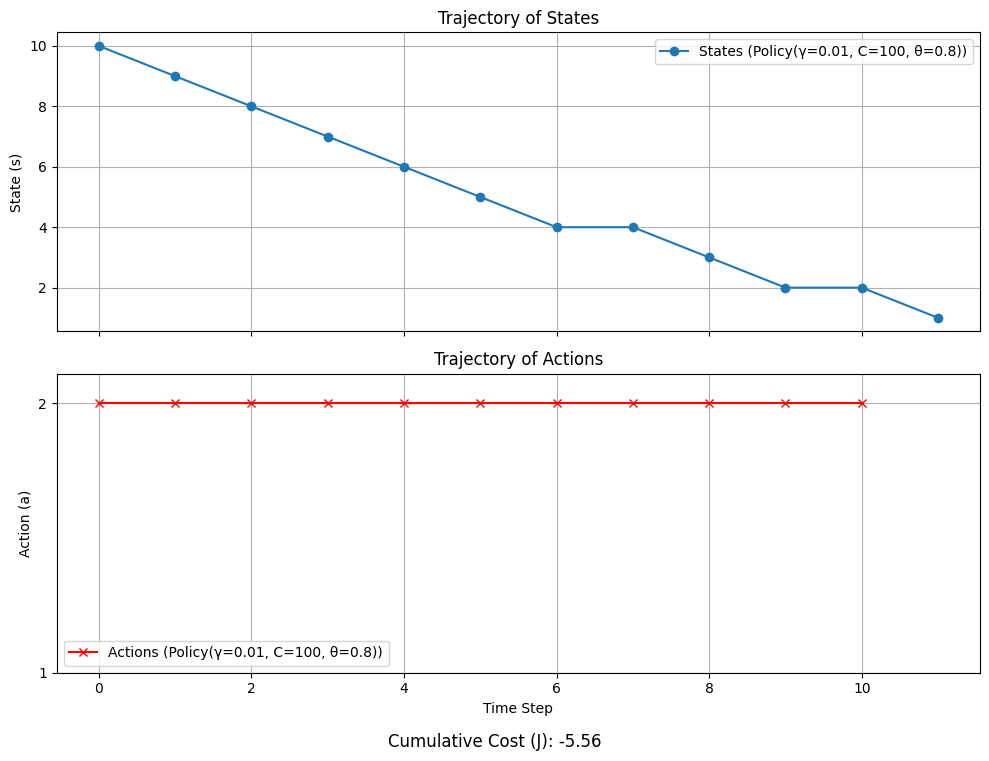


--- Large Gamma (gamma= 0.9 ) ---

--- Small Cost (C= 0.1 ) ---
Converged in 100 iterations.


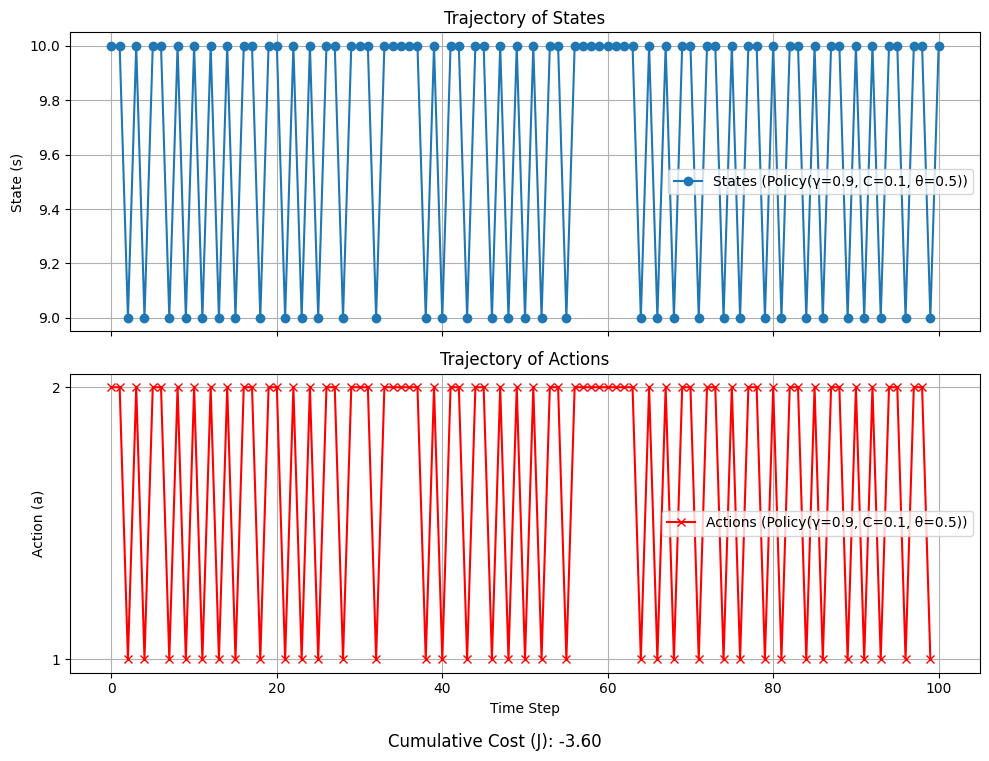

Converged in 94 iterations.


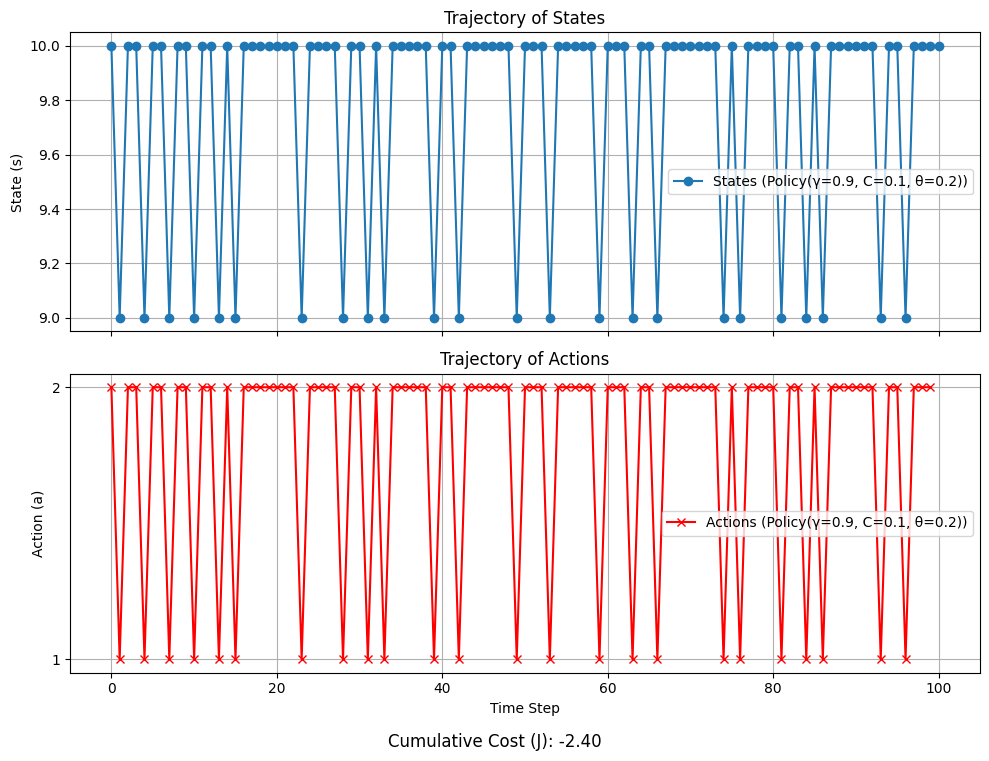

Converged in 103 iterations.


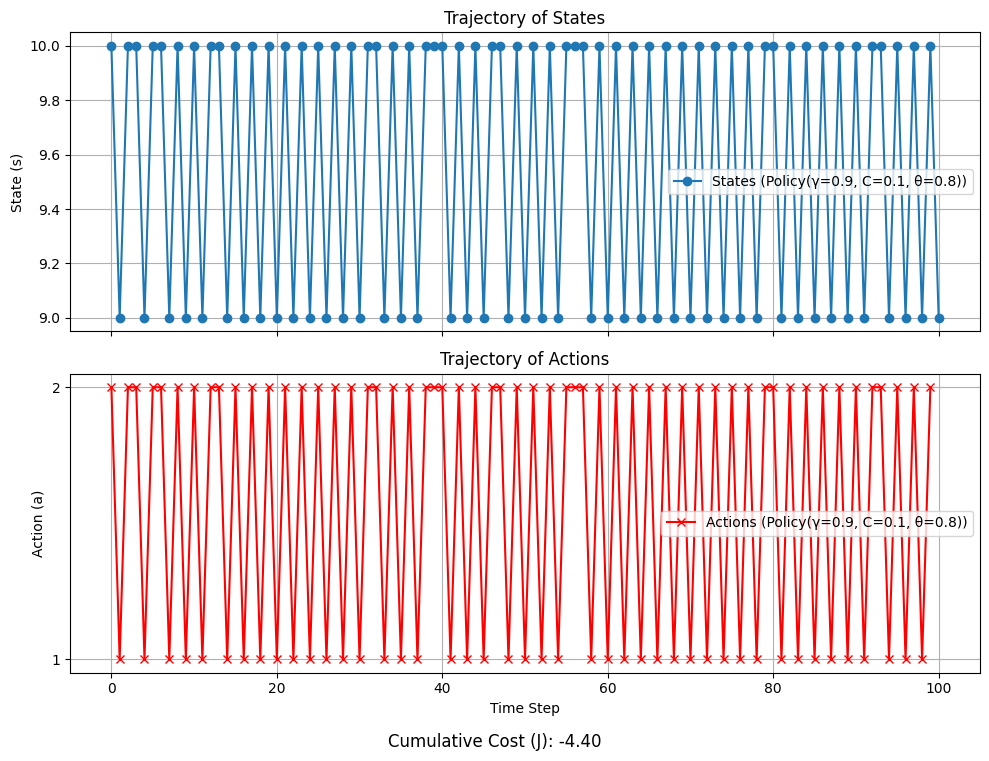


--- Mid Cost (C= 0.5 ) ---
Converged in 115 iterations.


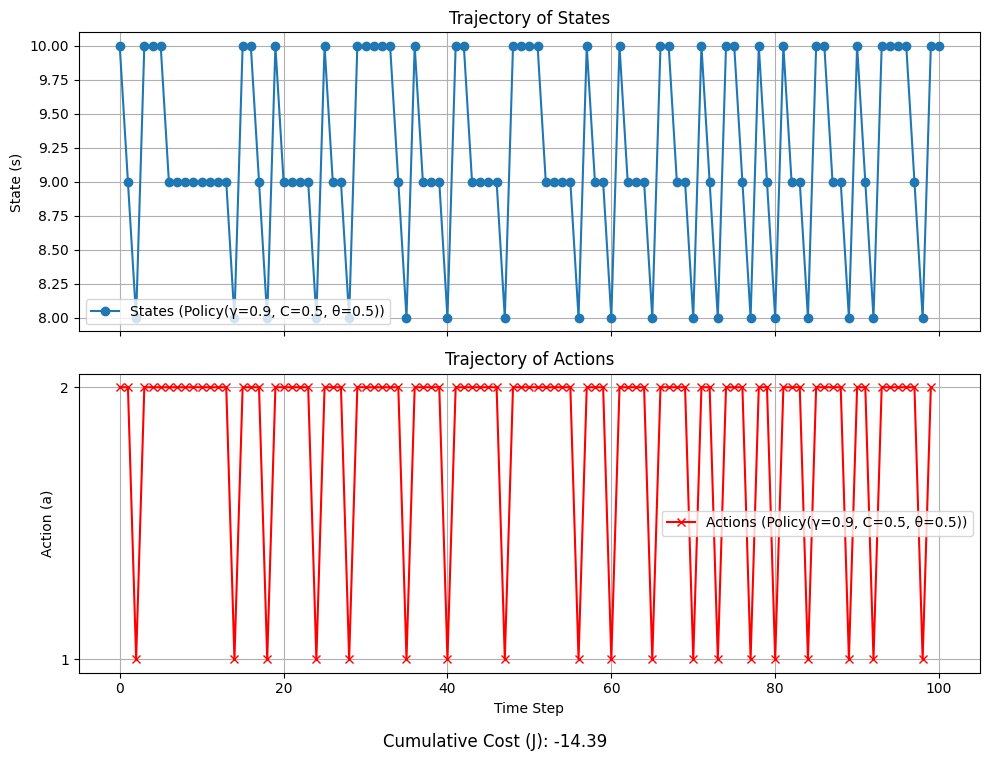

Converged in 111 iterations.


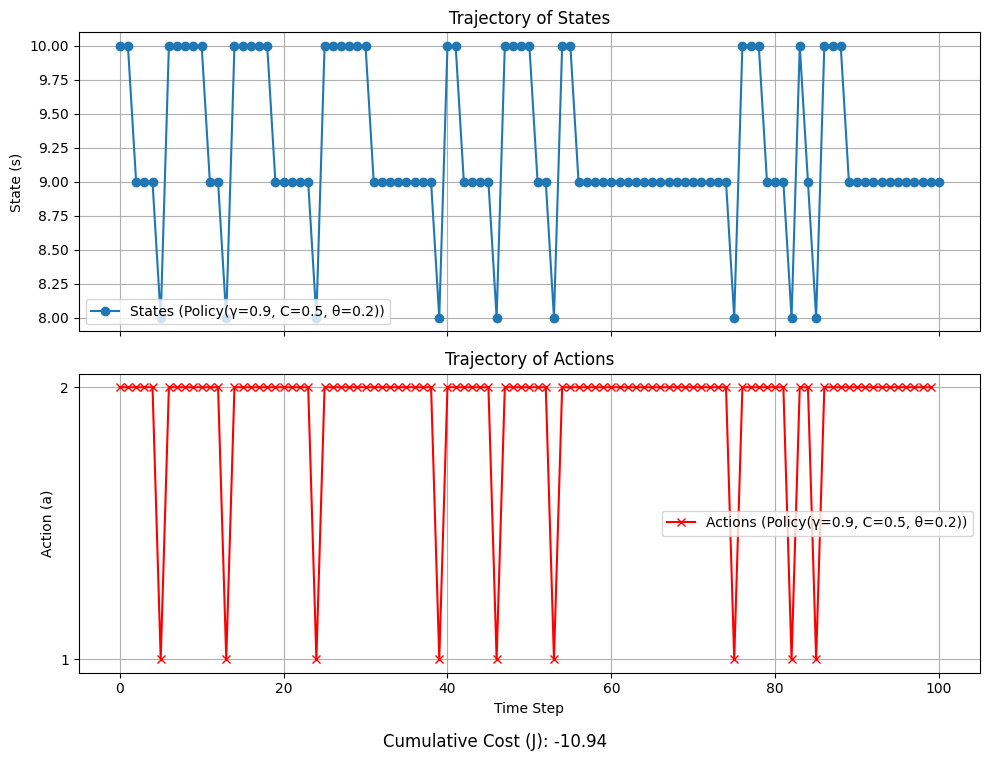

Converged in 117 iterations.


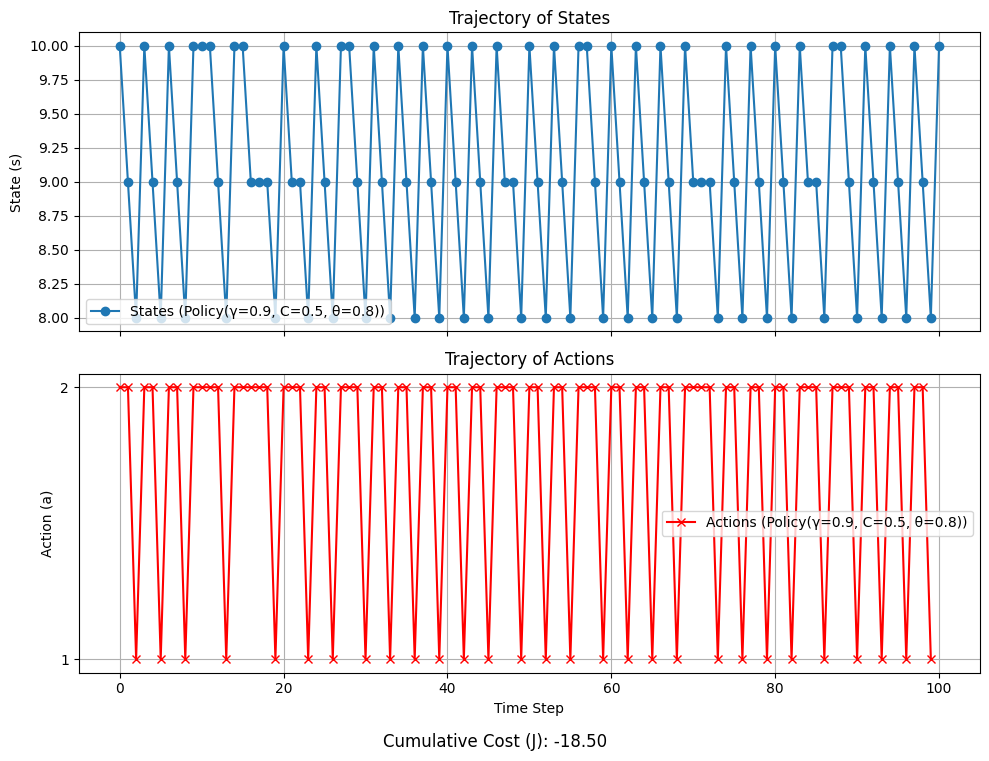


--- Large Cost (C= 100 ) ---
Converged in 133 iterations.


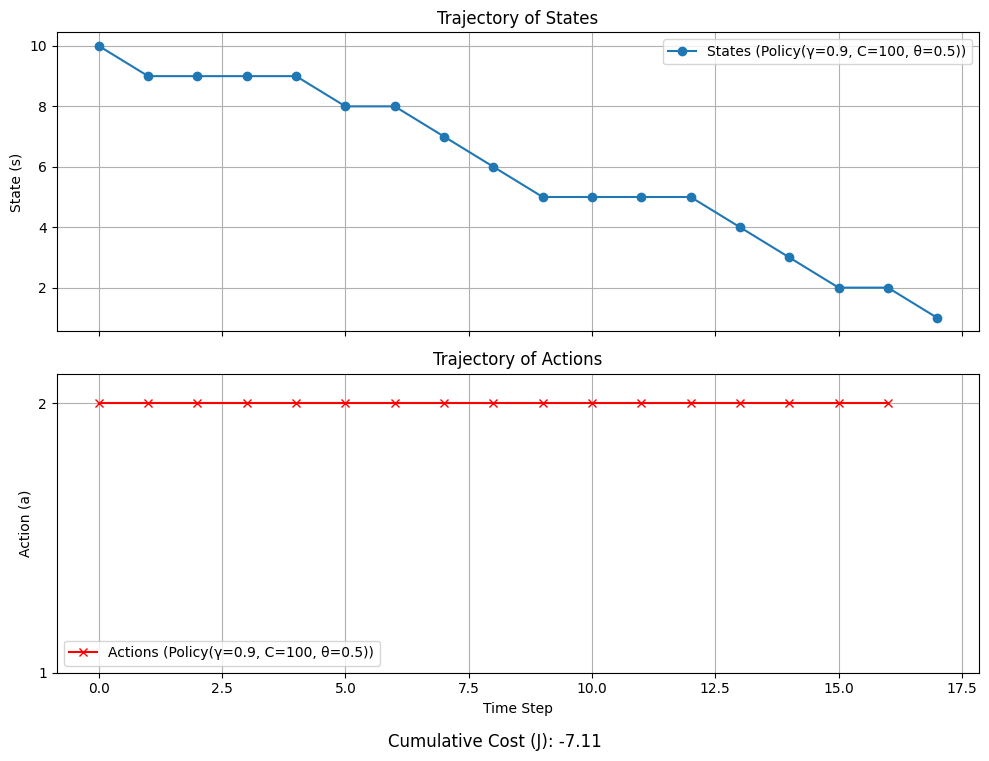

Converged in 133 iterations.


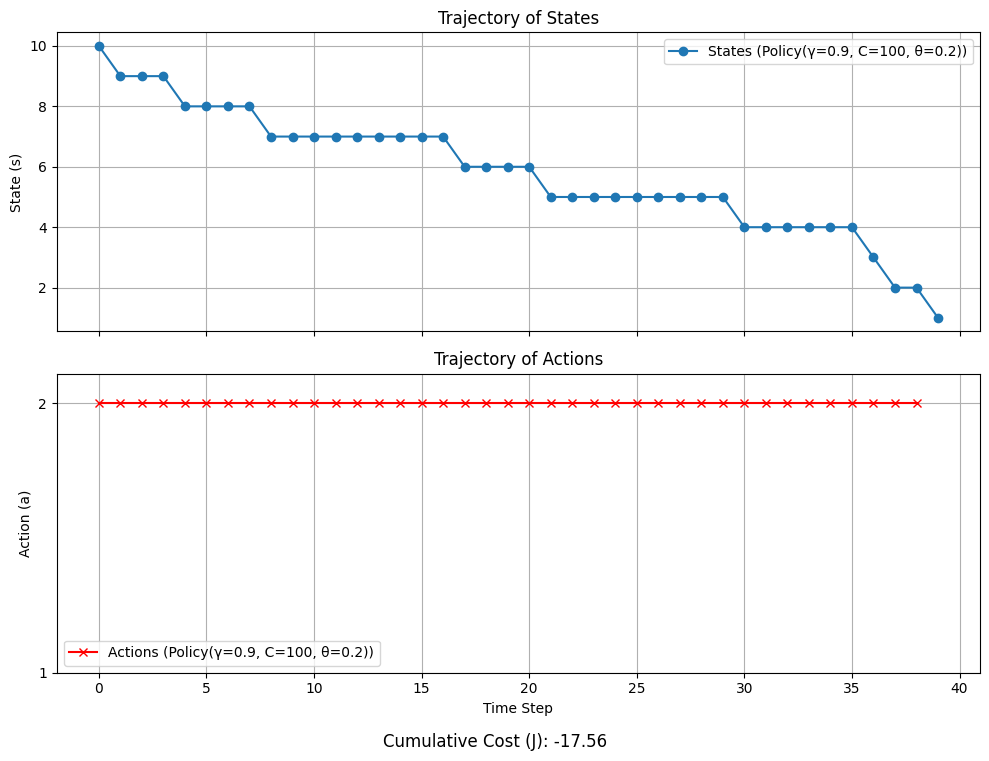

Converged in 133 iterations.


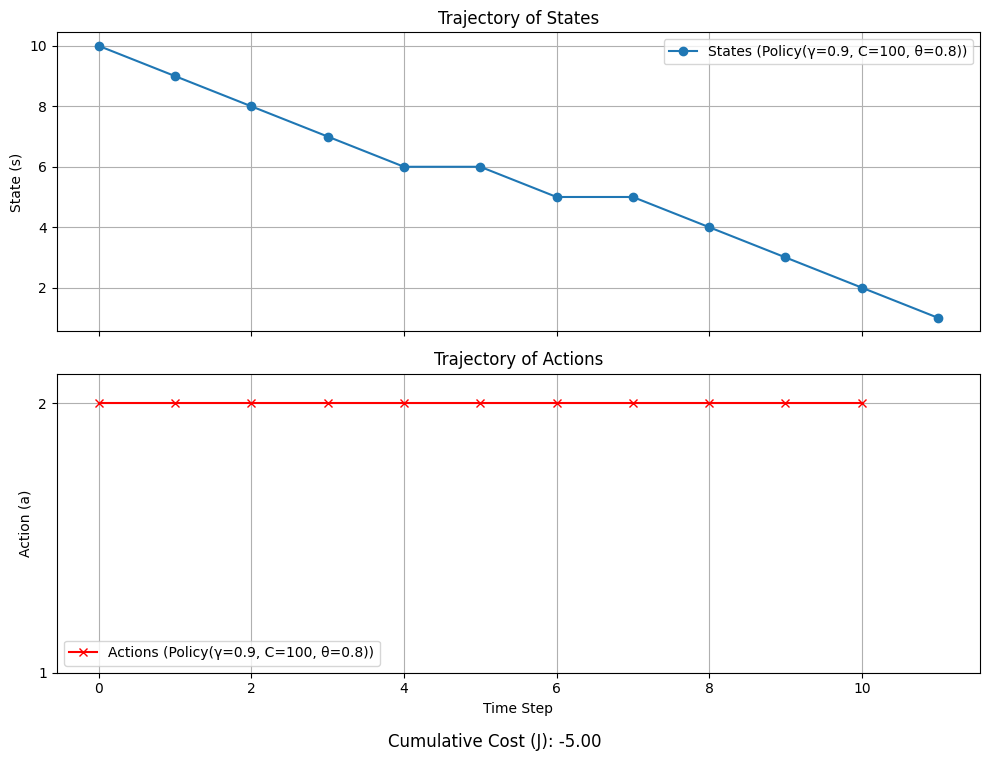

In [7]:
'''
Response 6 (Implementation Part - for small/big cost, γ, and theta)
'''

if __name__ == '__main__':
    # Default values used for S (states) and theta (probability of degradation)
    S = 10
    theta_default = 0.5  # Default theta

    gamma_small = 0.01
    gamma_large = 0.9
    C_small = 0.1
    C_mid = 0.5
    C_large = 100

    theta_small = 0.2
    theta_large = 0.8  # Define theta_small and theta_large

    # --- Small Gamma ---
    print("\n--- Small Gamma (gamma=", gamma_small, ") ---")

    # Small Cost
    print("\n--- Small Cost (C=", C_small, ") ---")
    _, pi_array_s_gamma_s_C, _ = value_iteration(gamma_small, C=C_small, theta=theta_default)
    pi_s_gamma_s_C = lambda s: pi_array_s_gamma_s_C[s - 1]
    plot_trajectory(pi_s_gamma_s_C, S, theta_default, C_small, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_small}, θ={theta_default})")

    _, pi_array_s_gamma_s_C_small_theta, _ = value_iteration(gamma_small, C=C_small, theta=theta_small)
    pi_s_gamma_s_C_small_theta = lambda s: pi_array_s_gamma_s_C_small_theta[s - 1]
    plot_trajectory(pi_s_gamma_s_C_small_theta, S, theta_small, C_small, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_small}, θ={theta_small})")

    _, pi_array_s_gamma_s_C_large_theta, _ = value_iteration(gamma_small, C=C_small, theta=theta_large)
    pi_s_gamma_s_C_large_theta = lambda s: pi_array_s_gamma_s_C_large_theta[s - 1]
    plot_trajectory(pi_s_gamma_s_C_large_theta, S, theta_large, C_small, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_small}, θ={theta_large})")


    # Mid Cost
    print("\n--- Mid Cost (C=", C_mid, ") ---")
    _, pi_array_s_gamma_m_C, _ = value_iteration(gamma_small, C=C_mid, theta=theta_default)
    pi_s_gamma_m_C = lambda s: pi_array_s_gamma_m_C[s - 1]
    plot_trajectory(pi_s_gamma_m_C, S, theta_default, C_mid, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_mid}, θ={theta_default})")

    _, pi_array_s_gamma_m_C_small_theta, _ = value_iteration(gamma_small, C=C_mid, theta=theta_small)
    pi_s_gamma_m_C_small_theta = lambda s: pi_array_s_gamma_m_C_small_theta[s - 1]
    plot_trajectory(pi_s_gamma_m_C_small_theta, S, theta_small, C_mid, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_mid}, θ={theta_small})")

    _, pi_array_s_gamma_m_C_large_theta, _ = value_iteration(gamma_small, C=C_mid, theta=theta_large)
    pi_s_gamma_m_C_large_theta = lambda s: pi_array_s_gamma_m_C_large_theta[s - 1]
    plot_trajectory(pi_s_gamma_m_C_large_theta, S, theta_large, C_mid, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_mid}, θ={theta_large})")

    # Large Cost
    print("\n--- Large Cost (C=", C_large, ") ---")
    _, pi_array_s_gamma_l_C, _ = value_iteration(gamma_small, C=C_large, theta=theta_default)
    pi_s_gamma_l_C = lambda s: pi_array_s_gamma_l_C[s - 1]
    plot_trajectory(pi_s_gamma_l_C, S, theta_default, C_large, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_large}, θ={theta_default})")

    _, pi_array_s_gamma_l_C_small_theta, _ = value_iteration(gamma_small, C=C_large, theta=theta_small)
    pi_s_gamma_l_C_small_theta = lambda s: pi_array_s_gamma_l_C_small_theta[s - 1]
    plot_trajectory(pi_s_gamma_l_C_small_theta, S, theta_small, C_large, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_large}, θ={theta_small})")

    _, pi_array_s_gamma_l_C_large_theta, _ = value_iteration(gamma_small, C=C_large, theta=theta_large)
    pi_s_gamma_l_C_large_theta = lambda s: pi_array_s_gamma_l_C_large_theta[s - 1]
    plot_trajectory(pi_s_gamma_l_C_large_theta, S, theta_large, C_large, gamma_small,
                    policy_name=f"Policy(γ={gamma_small}, C={C_large}, θ={theta_large})")

    # --- Large Gamma ---
    print("\n--- Large Gamma (gamma=", gamma_large, ") ---")

    # Small Cost
    print("\n--- Small Cost (C=", C_small, ") ---")
    _, pi_array_l_gamma_s_C, _ = value_iteration(gamma_large, C=C_small, theta=theta_default)
    pi_l_gamma_s_C = lambda s: pi_array_l_gamma_s_C[s - 1]
    plot_trajectory(pi_l_gamma_s_C, S, theta_default, C_small, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_small}, θ={theta_default})")

    _, pi_array_l_gamma_s_C_small_theta, _ = value_iteration(gamma_large, C=C_small, theta=theta_small)
    pi_l_gamma_s_C_small_theta = lambda s: pi_array_l_gamma_s_C_small_theta[s - 1]
    plot_trajectory(pi_l_gamma_s_C_small_theta, S, theta_small, C_small, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_small}, θ={theta_small})")

    _, pi_array_l_gamma_s_C_large_theta, _ = value_iteration(gamma_large, C=C_small, theta=theta_large)
    pi_l_gamma_s_C_large_theta = lambda s: pi_array_l_gamma_s_C_large_theta[s - 1]
    plot_trajectory(pi_l_gamma_s_C_large_theta, S, theta_large, C_small, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_small}, θ={theta_large})")


    # Mid Cost
    print("\n--- Mid Cost (C=", C_mid, ") ---")
    _, pi_array_l_gamma_m_C, _ = value_iteration(gamma_large, C=C_mid, theta=theta_default)
    pi_l_gamma_m_C = lambda s: pi_array_l_gamma_m_C[s - 1]
    plot_trajectory(pi_l_gamma_m_C, S, theta_default, C_mid, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_mid}, θ={theta_default})")

    _, pi_array_l_gamma_m_C_small_theta, _ = value_iteration(gamma_large, C=C_mid, theta=theta_small)
    pi_l_gamma_m_C_small_theta = lambda s: pi_array_l_gamma_m_C_small_theta[s - 1]
    plot_trajectory(pi_l_gamma_m_C_small_theta, S, theta_small, C_mid, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_mid}, θ={theta_small})")

    _, pi_array_l_gamma_m_C_large_theta, _ = value_iteration(gamma_large, C=C_mid, theta=theta_large)
    pi_l_gamma_m_C_large_theta = lambda s: pi_array_l_gamma_m_C_large_theta[s - 1]
    plot_trajectory(pi_l_gamma_m_C_large_theta, S, theta_large, C_mid, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_mid}, θ={theta_large})")

    # Large Cost
    print("\n--- Large Cost (C=", C_large, ") ---")
    _, pi_array_l_gamma_l_C, _ = value_iteration(gamma_large, C=C_large, theta=theta_default)
    pi_l_gamma_l_C = lambda s: pi_array_l_gamma_l_C[s - 1]
    plot_trajectory(pi_l_gamma_l_C, S, theta_default, C_large, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_large}, θ={theta_default})")

    _, pi_array_l_gamma_l_C_small_theta, _ = value_iteration(gamma_large, C=C_large, theta=theta_small)
    pi_l_gamma_l_C_small_theta = lambda s: pi_array_l_gamma_l_C_small_theta[s - 1]
    plot_trajectory(pi_l_gamma_l_C_small_theta, S, theta_small, C_large, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_large}, θ={theta_small})")

    _, pi_array_l_gamma_l_C_large_theta, _ = value_iteration(gamma_large, C=C_large, theta=theta_large)
    pi_l_gamma_l_C_large_theta = lambda s: pi_array_l_gamma_l_C_large_theta[s - 1]
    plot_trajectory(pi_l_gamma_l_C_large_theta, S, theta_large, C_large, gamma_large,
                    policy_name=f"Policy(γ={gamma_large}, C={C_large}, θ={theta_large})")

### Basic of OpenAI Gym <a class="anchor" id="1"></a>



Install OpenAi Gym.

In [8]:
# !pip install numpy==1.23

# !pip install --upgrade numpy

# !pip install --upgrade gym

# !pip install --upgrade pygame

# !pip install --upgrade ale-py

# !pip uninstall -y numpy gym
!pip install numpy==1.23.5
!pip install gym

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
bigframes 2.4.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [1]:
import numpy as np
import gym
import pygame
try:
    import ale_py
    print(f"ale_py version: {ale_py.__version__}")
except ImportError:
    print("ale_py not installed or import failed.")

print(f"NumPy version: {np.__version__}")
print(f"Gym version: {gym.__version__}")
print(f"Pygame version: {pygame.__version__}")

ale_py version: 0.11.0
NumPy version: 1.23.5
Gym version: 0.25.2
Pygame version: 2.6.1


Here a simple test of the environement using the CartPole environement.

Episode finished after 19 timesteps


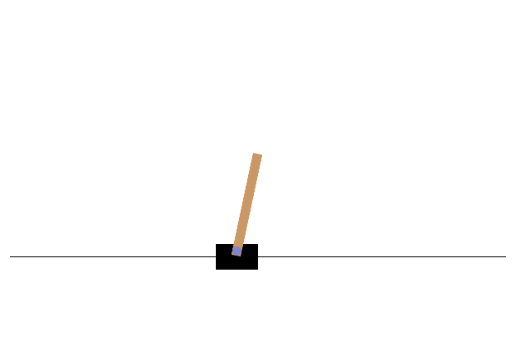

In [2]:
import gym
env = gym.make('CartPole-v1', render_mode='human')  # Used the updated environment from v0
for i_episode in range(20):
    observation = env.reset() # v1 returns observation and info (omitted in this version)
    for t in range(100):
        env.render()
        print(observation)  # gives the position, velocity, angle position, rotational speed of the pole
        action = env.action_space.sample()
        observation, reward, done, info = env.step(action) # v1 returns 4 values; done when pole falls out of balance/thresholds
        if done:
            print(f"Episode finished after {t+1} timesteps")   # varying timesteps because actions chosen at random
            break
env.close()


import gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# Create environment with rendering support for Colab
env = gym.make('CartPole-v1')  # No render_mode in old Gym

def show_frame(env):
    frame = env.render(mode='rgb_array')  # old API: use mode param
    plt.imshow(frame)
    plt.axis('off')
    display(plt.gcf())
    clear_output(wait=True)

for episode in range(5):
    obs = env.reset()
    for t in range(100):
        show_frame(env)
        action = env.action_space.sample()
        obs, reward, done, info = env.step(action)
        time.sleep(0.05)
        if done:
            # input("Press Enter to move to next episode...")
            print(f"Episode finished after {t+1} timesteps")
            break

env.close()




The environment is a class implementing the interface of the Gym environment. It is in this class that we will define states, actions, and the <code>step</code> function that is used here. The function <code>step</code> is taking as input an action and will return 4 elements:

- An observation : an object specific to our environment that corresponds to the observation obtained from it
- A reward
- done : indicate whether or not the simulation is over. **with the updated v1 environment, this appears as two argument *terminated* or *truncated***
- info : Extra info to debbug.

Please read a bit about the Gym environment by going through this link: https://www.gymlibrary.dev/content/basic_usage/

The action (resp. state) available to the agent are coded in a variable <code>action_space</code> (<code>observation_space</code>.). The classical spaces are <code>Discrete</code> abd <code>Box</code> :

- <code>Discrete(n)</code> = {0,1,...,n-1}
- <code>Box</code> is a box of size n, with a lower and upper terminal for each dimension.

The <code>render</code> function is used to display an "image" of the environment at time t.

Here is the shape of the interface corresponding to an OpenAi Gym environment:

```
import gym
from gym import spaces

class CustomEnv(gym.Env):
  """Custom Environment that follows gym interface"""
  metadata = {'render.modes': ['human']}

  def __init__(self, arg1, arg2, ...):
    super(CustomEnv, self).__init__()    
    
    # Define action and observation space
    # They must be gym.spaces objects    
    
    # Example when using discrete actions:
    self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)    
    
    # Example for using image as input:
    self.observation_space = spaces.Box(low=0, high=255, shape=
                    (HEIGHT, WIDTH, N_CHANNELS), dtype=np.uint8)

  def step(self, action):
    # Execute one time step within the environment
    ...  
    
  def reset(self):
    # Reset the state of the environment to an initial state
    ...  
    
  def render(self, mode='human', close=False):
    # Render the environment to the screen
    ...

```

### Creation of the machine replacement environment <a class="anchor" id="2"></a>

In [3]:
import scipy
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
import gym
from gym import spaces
import pandas as pd # Import pandas for creating tables

**7)** Machine environment: Implement the step function in the environment for the machine replacement problem. Test it and compare it with the function *simulation* implemented before.

In [7]:
class Machine_env(gym.Env):

    metadata = {'render.modes': ['human']}
    """Machine Replacement Environment following GymEnv interface model shape"""

    def __init__(self, S, θ, C, max_iter = 100):
        super(Machine_env, self).__init__()

        self.action_space = spaces.Discrete(2)


        self.observation_space = spaces.Discrete(S)
        self.state = S-1
        self.new = S-1
        self.p_break = θ    # probability that the machine will break
        self.cost = C
        self.traj = [self.new]
        self.max_iter = max_iter

    def step(self, action):
        # Execute one time step within the environment
        # action is 0 (replace) or 1 (leave unchanged)
        reward = 0
        done = False
        info = {}

        if action == 0:  # Replace
            self.state = self.new
            reward = -self.cost
        elif action == 1:  # Leave unchanged
            if self.state == 0:  # Already broken
                reward = -(self.new / (self.new )) if self.new > 0 else -1.0  # Avoid division by 0; Minimum cost
            else:
                reward = -(self.new - self.state) / (self.new) if self.new > 0 else 0.0  # Avoid division by zero; Cost is proportional to degradation
            # Degrade the machine
            if self.state > 0:
                if np.random.rand() < self.p_break:   # artificially implement probabilistic behaviour extracting from 0-1 unifrom dist
                    self.state -= 1   # degrade if probability is less than threshold for breaking
        else:
            raise ValueError(f"Invalid action: {action}")

        self.traj.append(self.state)

        if len(self.traj) >= self.max_iter or self.state == 0:   # equivalent of cartPole falling out of balance
            done = True

        observation = np.array([self.state], dtype=np.int32) # Gym expects an array


        return observation, reward, done, info

        # return observation, reward-1, done, info




    def reset(self):
    # Reset the state of the environment to an initial state
        self.state = self.new
        plt.clf()
        self.traj = [self.new]
        return np.array([self.state])

    def render(self, mode='human', close=False):
    # Render the environment to the screen
        plt.clf()
        plt.xlabel("Time")
        plt.ylabel("Machine State")
        plt.scatter(range(len(self.traj)),self.traj)
        plt.show()
        plt.pause(0.01)
        print("State : ", self.state)

    def close(self):
        plt.close()


=== Test 1: Environment Creation ===
Action space: Discrete(2)
Observation space: Discrete(5)
Initial state: 4
Break probability: 0.3
Replacement cost: 10

=== Test 2: Reset ===
After reset - Observation: [4]
After reset - State: 4
Trajectory: [4]

=== Test 3: Single Steps ===
Action 0 (Replace) - Obs: [4], Reward: -10, Done: False
Action 1 (Leave) - Obs: [4], Reward: 0.0, Done: False

=== Test 4: Random Episode ===
Step 1: Action=1, State=4, Reward=0.00, Done=False
Step 2: Action=0, State=4, Reward=-10.00, Done=False
Step 3: Action=0, State=4, Reward=-10.00, Done=False
Step 4: Action=1, State=4, Reward=0.00, Done=False
Step 5: Action=1, State=4, Reward=0.00, Done=False
Step 6: Action=0, State=4, Reward=-10.00, Done=False
Step 7: Action=0, State=4, Reward=-10.00, Done=False
Step 8: Action=0, State=4, Reward=-10.00, Done=False
Step 9: Action=0, State=4, Reward=-10.00, Done=False
Step 10: Action=1, State=3, Reward=0.00, Done=False
Step 11: Action=1, State=2, Reward=-0.25, Done=False
Step

<Figure size 640x480 with 0 Axes>

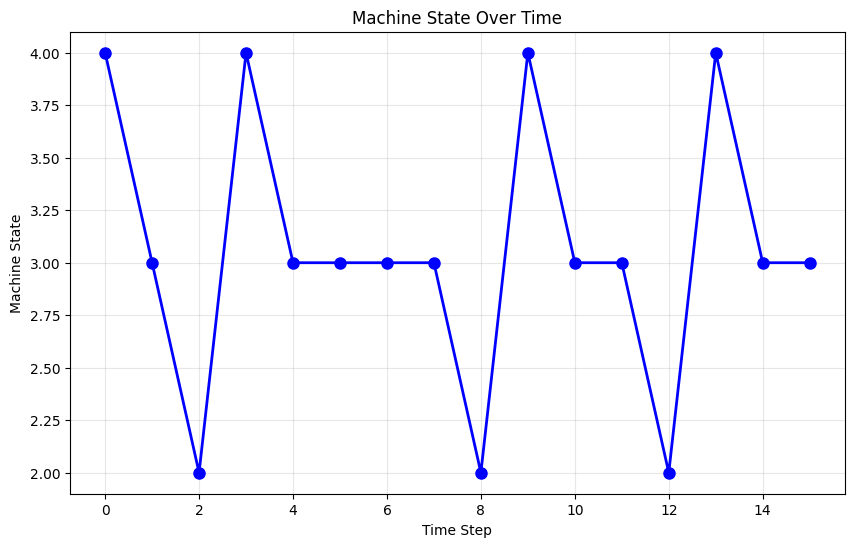


=== Test 7: Environment Validation ===
✓ Correctly caught invalid action: Invalid action: 2
✓ Reset consistency: State after reset 1: 4, State after reset 2: 4

=== All Tests Complete! ===
Your Machine_env appears to be working correctly!


<Figure size 640x480 with 0 Axes>

In [8]:
if __name__ == '__main__':
    # Basic Environment Creation and Info
    print("=== Test 1: Environment Creation ===")
    env = Machine_env(S=5, θ=0.3, C=10, max_iter=50)
    print(f"Action space: {env.action_space}")
    print(f"Observation space: {env.observation_space}")
    print(f"Initial state: {env.state}")
    print(f"Break probability: {env.p_break}")
    print(f"Replacement cost: {env.cost}")

    # Reset functionality
    print("\n=== Test 2: Reset ===")
    initial_obs = env.reset()
    print(f"After reset - Observation: {initial_obs}")
    print(f"After reset - State: {env.state}")
    print(f"Trajectory: {env.traj}")

    # Single step with different actions
    print("\n=== Test 3: Single Steps ===")
    env.reset()

    # Test replace action (0)
    obs, reward, done, info = env.step(0)
    print(f"Action 0 (Replace) - Obs: {obs}, Reward: {reward}, Done: {done}")

    # Test leave unchanged action (1)
    obs, reward, done, info = env.step(1)
    print(f"Action 1 (Leave) - Obs: {obs}, Reward: {reward}, Done: {done}")

    # Full episode with random actions
    print("\n=== Test 4: Random Episode ===")
    env.reset()
    episode_rewards = []
    episode_states = []

    for step in range(20):  # Limit to 20 steps for readability
        action = env.action_space.sample()  # Random action
        obs, reward, done, info = env.step(action)

        episode_rewards.append(reward)
        episode_states.append(obs[0])

        print(f"Step {step+1}: Action={action}, State={obs[0]}, Reward={reward:.2f}, Done={done}")

        if done:
            print(f"Episode finished after {step+1} steps")
            break

    print(f"Total reward: {sum(episode_rewards):.2f}")
    print(f"Final trajectory: {env.traj}")

    # Policy-based episode (always replace when state < 3)
    print("\n=== Test 5: Policy-Based Episode ===")
    env.reset()
    episode_rewards = []

    for step in range(30):
        current_state = env.state

        # Simple policy: replace if state drops below 3
        if current_state < 3:
            action = 0  # Replace
        else:
            action = 1  # Leave unchanged

        obs, reward, done, info = env.step(action)
        episode_rewards.append(reward)

        action_name = "Replace" if action == 0 else "Leave"
        print(f"Step {step+1}: State={current_state}, Action={action_name}, Reward={reward:.2f}, New_State={obs[0]}, Done={done}")

        if done:
            print(f"Episode finished after {step+1} steps")
            break

    print(f"Total reward: {sum(episode_rewards):.2f}")

    # Visualization
    print("\n=== Test 6: Visualization ===")
    env.reset()
    plt.figure(figsize=(10, 6))

    # Run a short episode and plot
    for step in range(15):
        action = 1 if env.state > 2 else 0  # Replace when state <= 2
        obs, reward, done, info = env.step(action)
        if done:
            break

    # Plot the trajectory
    plt.plot(range(len(env.traj)), env.traj, 'bo-', linewidth=2, markersize=8)
    plt.xlabel("Time Step")
    plt.ylabel("Machine State")
    plt.title("Machine State Over Time")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Environment validation
    print("\n=== Test 7: Environment Validation ===")
    try:
        # Test invalid action
        env.reset()
        env.step(2)  # Invalid action (should be 0 or 1)
    except ValueError as e:
        print(f"✓ Correctly caught invalid action: {e}")

    # Test multiple resets
    env.reset()
    state1 = env.state
    env.reset()
    state2 = env.state
    print(f"✓ Reset consistency: State after reset 1: {state1}, State after reset 2: {state2}")

    print("\n=== All Tests Complete! ===")
    print("Your Machine_env appears to be working correctly!")

=== Machine Environment Visualization Demo ===

Running episode with policy: Replace when state ≤ 2

1. Comprehensive Analysis:


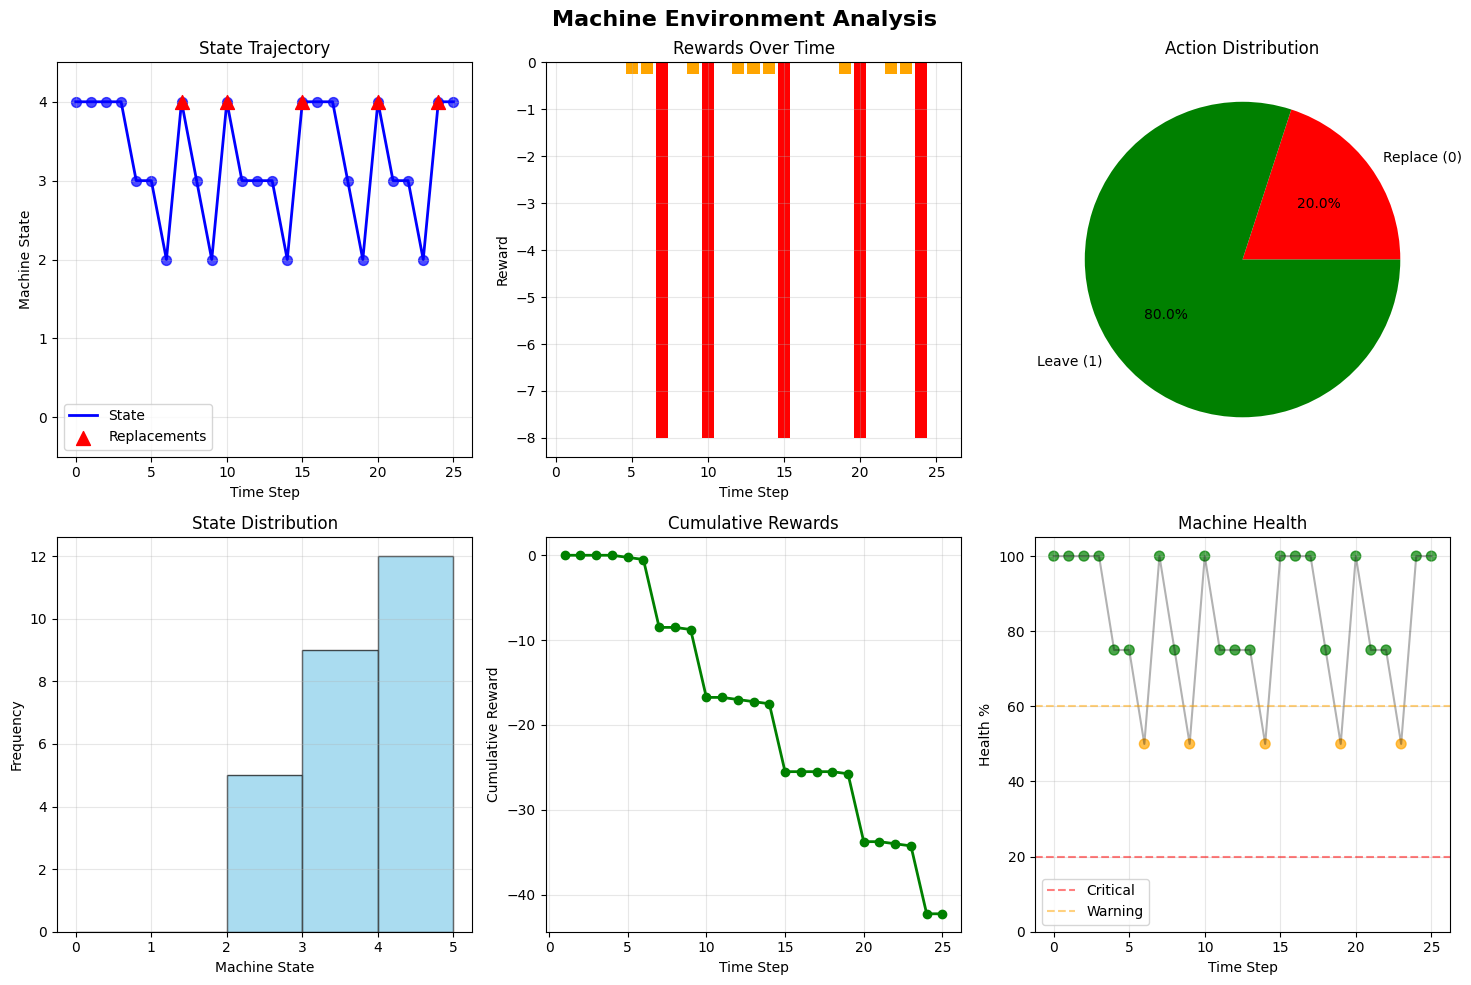


=== Episode Summary ===
Total Steps: 25
Total Reward: -42.25
Replacements: 5
Leave Actions: 20
Final State: 4
Episode Ended: Max Steps Reached

2. Simple Current State:


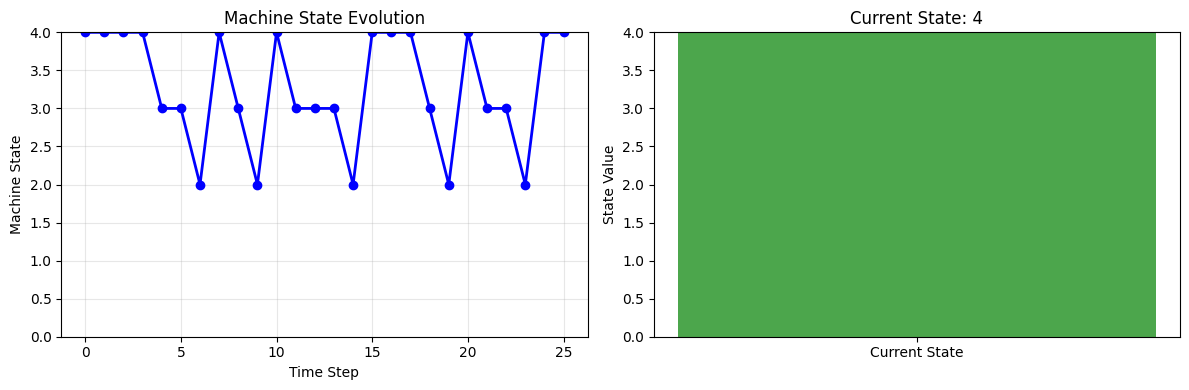


3. Episode Data Analysis:
   Step  State_Before   Action  State_After  Reward  Cumulative_Reward
0     0             4    Leave            4    0.00               0.00
1     1             4    Leave            4    0.00               0.00
2     2             4    Leave            4    0.00               0.00
3     3             4    Leave            3    0.00               0.00
4     4             3    Leave            3   -0.25              -0.25
5     5             3    Leave            2   -0.25              -0.50
6     6             2  Replace            4   -8.00              -8.50
7     7             4    Leave            3    0.00              -8.50
8     8             3    Leave            2   -0.25              -8.75
9     9             2  Replace            4   -8.00             -16.75

DataFrame shape: (25, 6)


In [81]:
plt.ion()  # Interactive mode for Colab
%matplotlib inline

class Machine_env(gym.Env):
    metadata = {'render.modes': ['human', 'rgb_array']}

    def __init__(self, S, θ, C, max_iter=100):
        super(Machine_env, self).__init__()

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(S)
        self.state = S-1
        self.new = S-1
        self.p_break = θ
        self.cost = C
        self.traj = [self.new]
        self.actions_taken = []
        self.rewards_history = []
        self.max_iter = max_iter

    def step(self, action):
        reward = 0
        done = False
        info = {}

        if action == 0:  # Replace
            self.state = self.new
            reward = -self.cost
        elif action == 1:  # Leave unchanged
            if self.state == 0:  # Already broken
                reward = -(self.new / self.new) if self.new > 0 else -1.0
            else:
                reward = -(self.new - self.state) / self.new if self.new > 0 else 0.0
            # Degrade the machine
            if self.state > 0:
                if np.random.rand() < self.p_break:
                    self.state -= 1
        else:
            raise ValueError(f"Invalid action: {action}")

        self.traj.append(self.state)
        self.actions_taken.append(action)
        self.rewards_history.append(reward)

        if len(self.traj) >= self.max_iter or self.state == 0:
            done = True

        observation = np.array([self.state], dtype=np.int32)
        return observation, reward, done, info

    def reset(self):
        self.state = self.new
        self.traj = [self.new]
        self.actions_taken = []
        self.rewards_history = []
        return np.array([self.state])

    def render_comprehensive(self, figsize=(15, 10)):
        """Enhanced visualization with multiple subplots"""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Machine Environment Analysis', fontsize=16, fontweight='bold')

        # State trajectory with actions
        ax1 = axes[0, 0]
        steps = range(len(self.traj))
        ax1.plot(steps, self.traj, 'b-', linewidth=2, label='State')
        ax1.scatter(steps, self.traj, c='blue', s=50, alpha=0.7)

        # Mark replacement actions
        if self.actions_taken:
            replacements = [i+1 for i, action in enumerate(self.actions_taken) if action == 0]
            if replacements:
                replacement_states = [self.traj[i] for i in replacements]
                ax1.scatter(replacements, replacement_states, c='red', s=100,
                           marker='^', label='Replacements', zorder=5)

        ax1.set_xlabel('Time Step')
        ax1.set_ylabel('Machine State')
        ax1.set_title('State Trajectory')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_ylim(-0.5, self.new + 0.5)

        # Rewards over time
        ax2 = axes[0, 1]
        if self.rewards_history:
            ax2.bar(range(1, len(self.rewards_history)+1), self.rewards_history,
                   color=['red' if r < -5 else 'orange' for r in self.rewards_history])
            ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax2.set_xlabel('Time Step')
            ax2.set_ylabel('Reward')
            ax2.set_title('Rewards Over Time')
            ax2.grid(True, alpha=0.3)

        # Action distribution
        ax3 = axes[0, 2]
        if self.actions_taken:
            action_counts = [self.actions_taken.count(0), self.actions_taken.count(1)]
            action_labels = ['Replace (0)', 'Leave (1)']
            colors = ['red', 'green']
            ax3.pie(action_counts, labels=action_labels, colors=colors, autopct='%1.1f%%')
            ax3.set_title('Action Distribution')

        # 4. State histogram
        ax4 = axes[1, 0]
        ax4.hist(self.traj, bins=range(self.new+2), alpha=0.7, color='skyblue',
                edgecolor='black')
        ax4.set_xlabel('Machine State')
        ax4.set_ylabel('Frequency')
        ax4.set_title('State Distribution')
        ax4.grid(True, alpha=0.3)

        # 5. Cumulative rewards
        ax5 = axes[1, 1]
        if self.rewards_history:
            cumulative_rewards = np.cumsum(self.rewards_history)
            ax5.plot(range(1, len(cumulative_rewards)+1), cumulative_rewards,
                    'g-', linewidth=2, marker='o')
            ax5.set_xlabel('Time Step')
            ax5.set_ylabel('Cumulative Reward')
            ax5.set_title('Cumulative Rewards')
            ax5.grid(True, alpha=0.3)

        # 6. Machine health indicator
        ax6 = axes[1, 2]
        if len(self.traj) > 1:
            health_pct = [(state / self.new) * 100 for state in self.traj]
            colors = ['red' if h < 20 else 'orange' if h < 60 else 'green' for h in health_pct]
            ax6.scatter(range(len(health_pct)), health_pct, c=colors, s=50, alpha=0.7)
            ax6.plot(range(len(health_pct)), health_pct, 'k-', alpha=0.3)
            ax6.set_xlabel('Time Step')
            ax6.set_ylabel('Health %')
            ax6.set_title('Machine Health')
            ax6.set_ylim(0, 105)
            ax6.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Critical')
            ax6.axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Warning')
            ax6.legend()
            ax6.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        if self.rewards_history:
            print(f"\n=== Episode Summary ===")
            print(f"Total Steps: {len(self.actions_taken)}")
            print(f"Total Reward: {sum(self.rewards_history):.2f}")
            print(f"Replacements: {self.actions_taken.count(0)}")
            print(f"Leave Actions: {self.actions_taken.count(1)}")
            print(f"Final State: {self.traj[-1]}")
            print(f"Episode Ended: {'Machine Broken' if self.traj[-1] == 0 else 'Max Steps Reached'}")

    def render_simple_animated(self):
        """Simple animated visualization"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # State over time
        ax1.plot(range(len(self.traj)), self.traj, 'bo-', linewidth=2)
        ax1.set_xlabel('Time Step')
        ax1.set_ylabel('Machine State')
        ax1.set_title('Machine State Evolution')
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(0, self.new)

        # Current state indicator
        current_state = self.traj[-1]
        state_colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
        if current_state < len(state_colors):
            color = state_colors[current_state]
        else:
            color = 'green'

        ax2.bar(['Current State'], [current_state], color=color, alpha=0.7)
        ax2.set_ylabel('State Value')
        ax2.set_title(f'Current State: {current_state}')
        ax2.set_ylim(0, self.new)

        # Add text annotations
        if current_state == 0:
            ax2.text(0, current_state + 0.1, 'BROKEN!', ha='center',
                    fontsize=12, fontweight='bold', color='red')
        elif current_state < self.new * 0.3:
            ax2.text(0, current_state + 0.1, 'CRITICAL', ha='center',
                    fontsize=10, fontweight='bold', color='orange')

        plt.tight_layout()
        plt.show()

    def get_episode_dataframe(self):
        """Convert episode data to pandas DataFrame for analysis"""
        if not self.actions_taken:
            return None

        df = pd.DataFrame({
            'Step': range(len(self.actions_taken)),
            'State_Before': self.traj[:-1],
            'Action': ['Replace' if a == 0 else 'Leave' for a in self.actions_taken],
            'State_After': self.traj[1:],
            'Reward': self.rewards_history,
            'Cumulative_Reward': np.cumsum(self.rewards_history)
        })
        return df

# Example usage and testing
def run_visualization_demo():
    print("=== Machine Environment Visualization Demo ===\n")

    # Create environment
    env = Machine_env(S=5, θ=0.4, C=8, max_iter=30)

    # Run episode with simple policy
    env.reset()
    print("Running episode with policy: Replace when state ≤ 2")

    for step in range(25):
        current_state = env.state
        action = 0 if current_state <= 2 else 1  # Replace if state <= 2
        obs, reward, done, info = env.step(action)

        if done:
            print(f"Episode ended at step {step + 1}")
            break

    # Show comprehensive visualization
    print("\n1. Comprehensive Analysis:")
    env.render_comprehensive()

    # Show simple visualization
    print("\n2. Simple Current State:")
    env.render_simple_animated()

    # Show data analysis
    print("\n3. Episode Data Analysis:")
    df = env.get_episode_dataframe()
    if df is not None:
        print(df.head(10))
        print(f"\nDataFrame shape: {df.shape}")

# Run the demo
run_visualization_demo()

=== Comprehensive Machine Environment Demo ===

1. Comparing policies...


<ipython-input-25-1a98daf63fd4>:450: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(reward_data, labels=labels)


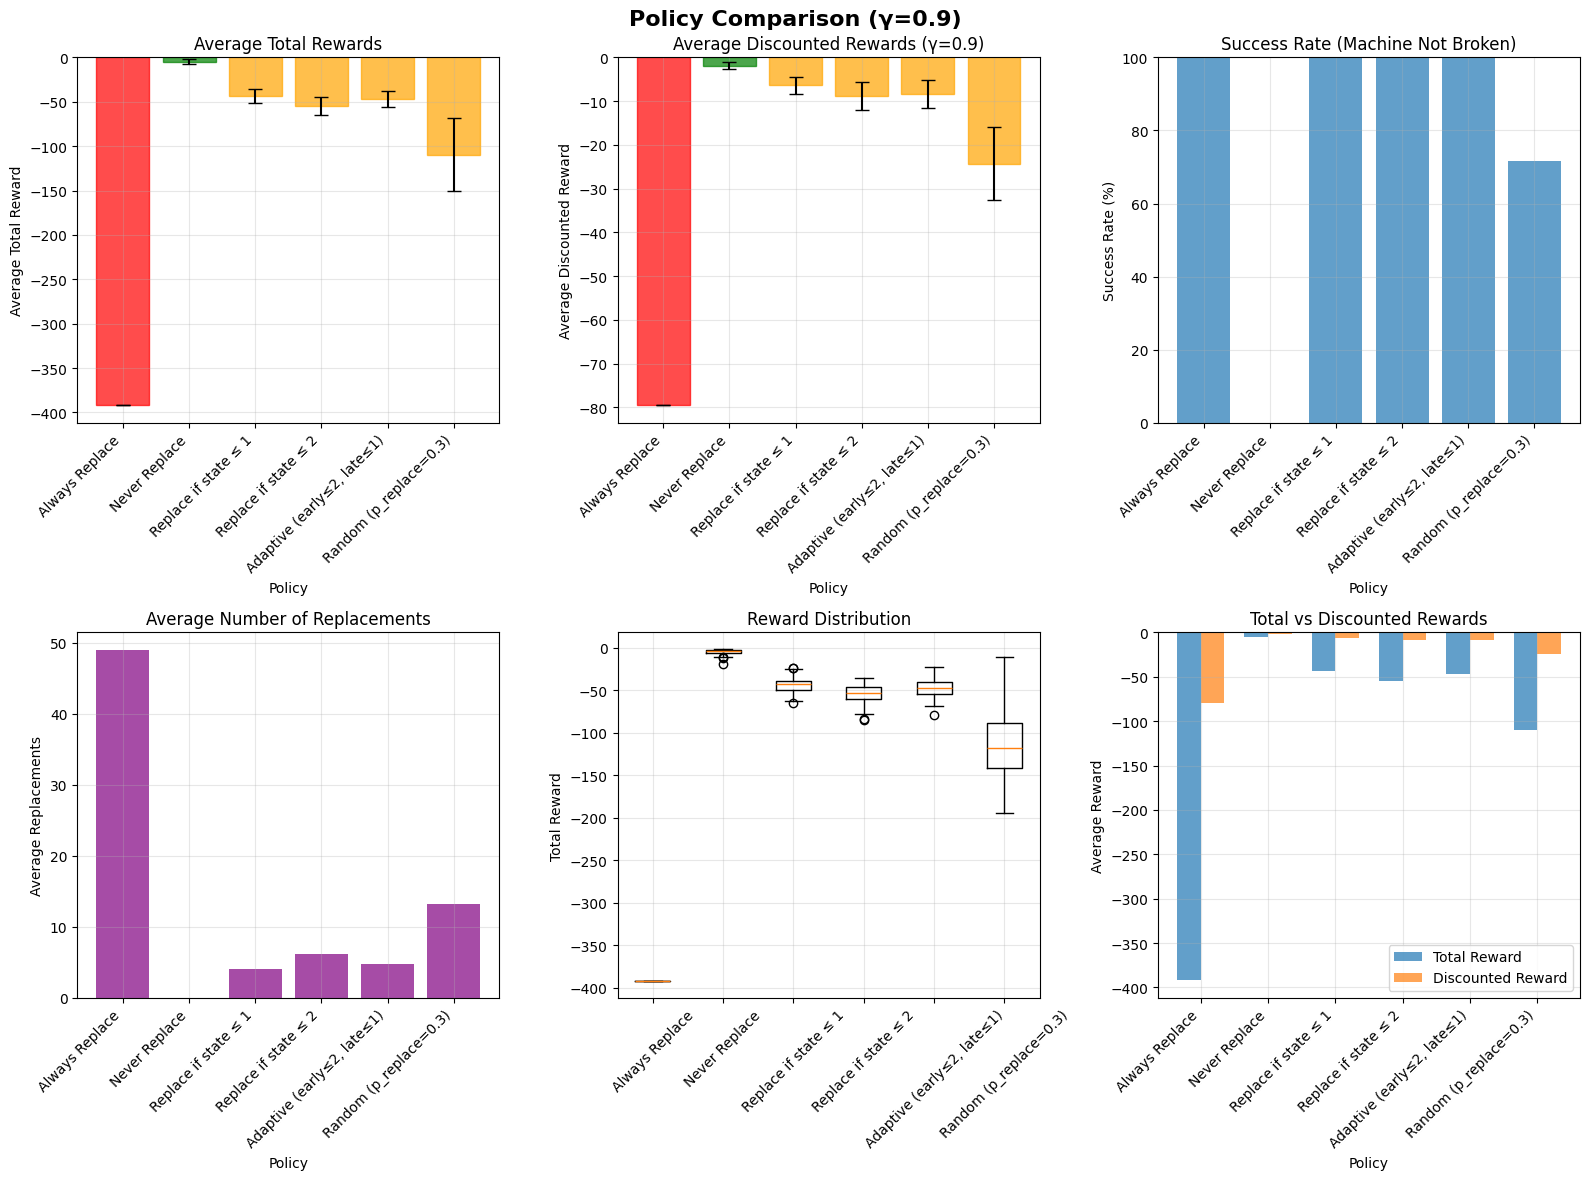


=== Policy Comparison Results ===
Environment: S=5, θ=0.3, C=8, γ=0.9
--------------------------------------------------------------------------------

Policy: Always Replace
  Average Total Reward: -392.00 ± 0.00
  Average Discounted Reward: -79.54 ± 0.00
  Average Steps: 49.0
  Average Replacements: 49.0
  Success Rate: 100.0%

Policy: Never Replace
  Average Total Reward: -4.95 ± 2.66
  Average Discounted Reward: -1.96 ± 0.79
  Average Steps: 13.4
  Average Replacements: 0.0
  Success Rate: 0.0%

Policy: Replace if state ≤ 1
  Average Total Reward: -43.61 ± 7.94
  Average Discounted Reward: -6.42 ± 2.04
  Average Steps: 49.0
  Average Replacements: 4.1
  Success Rate: 100.0%

Policy: Replace if state ≤ 2
  Average Total Reward: -54.65 ± 9.99
  Average Discounted Reward: -8.94 ± 3.19
  Average Steps: 49.0
  Average Replacements: 6.2
  Success Rate: 100.0%

Policy: Adaptive (early≤2, late≤1)
  Average Total Reward: -46.79 ± 9.17
  Average Discounted Reward: -8.44 ± 3.22
  Average Ste

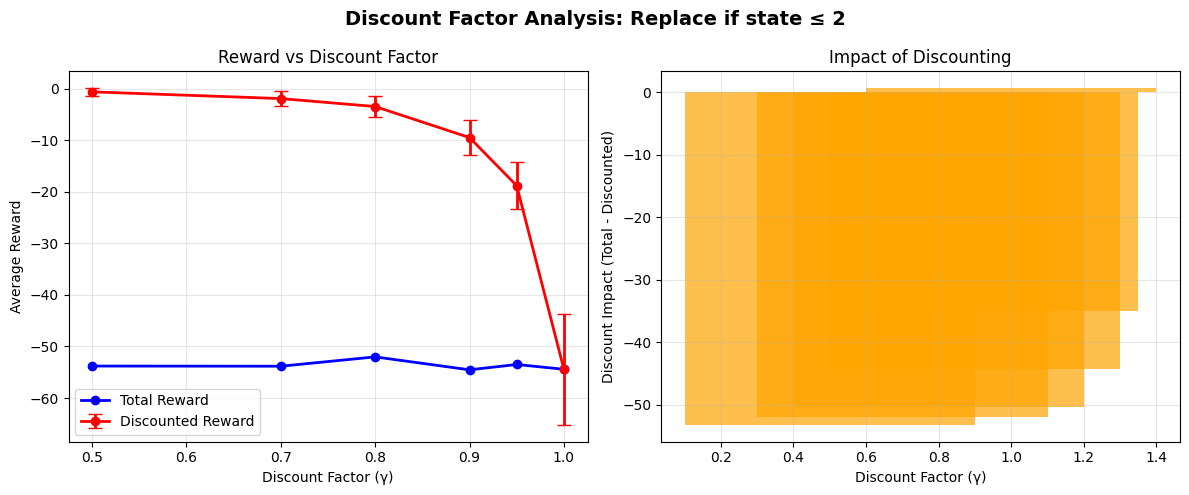


3. Single episode detailed analysis...


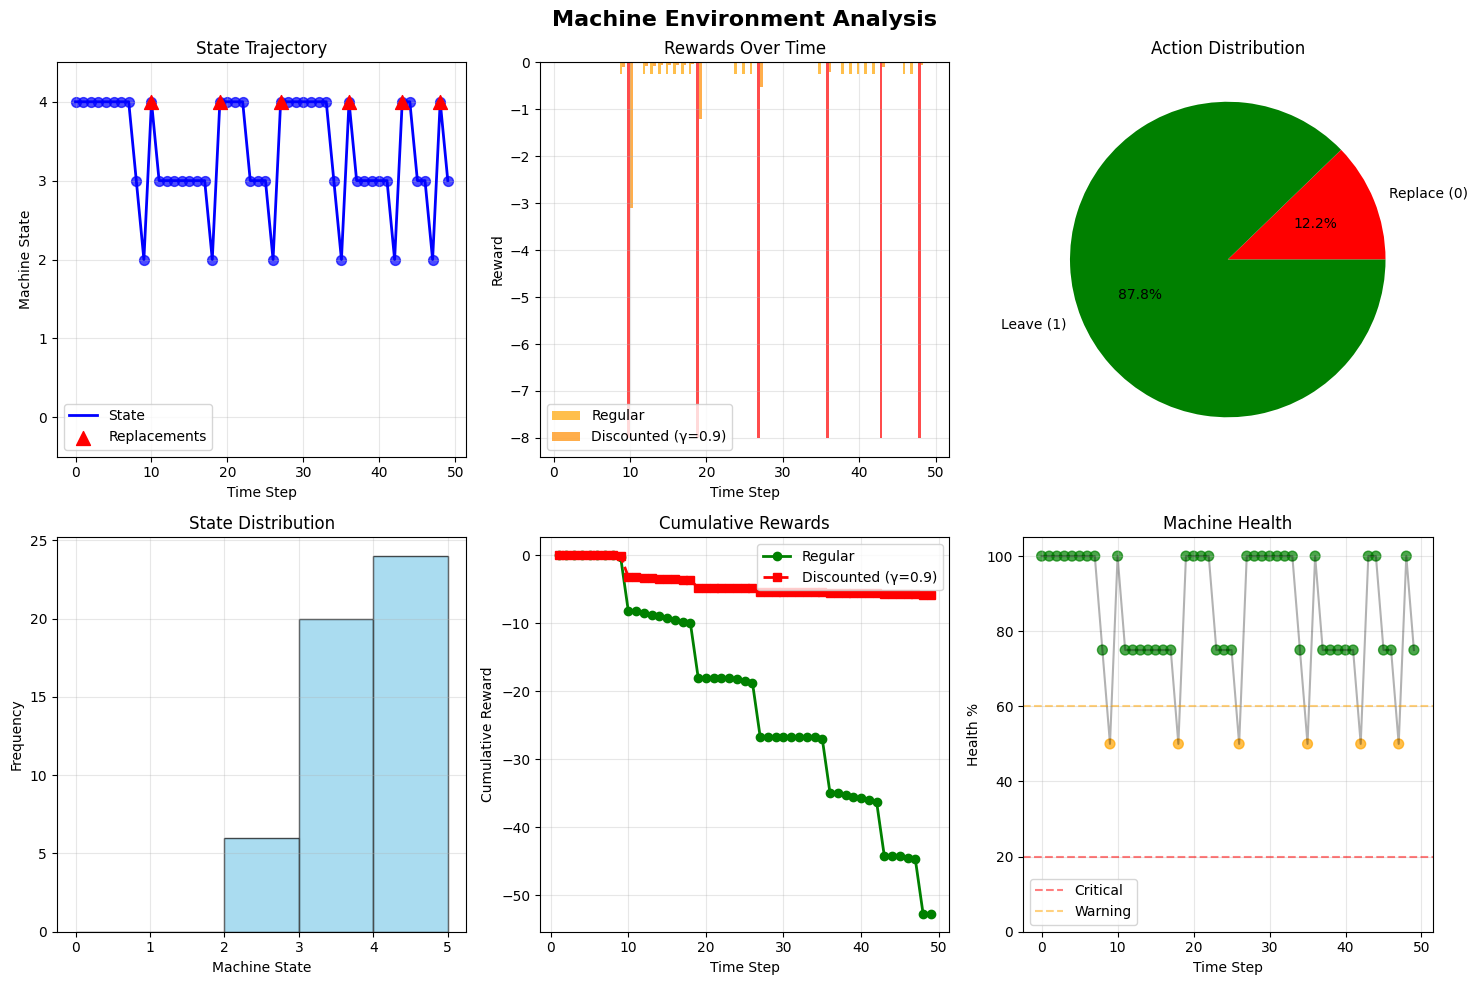


=== Episode Summary ===
Total Steps: 49
Total Reward: -52.75
Discounted Reward (γ=0.9): -5.78
Replacements: 6
Leave Actions: 43
Final State: 3
Episode Ended: Max Steps Reached


In [25]:
# Enhanced Machine Environment with Discount Factor and Policy Comparison

import gym
from gym import spaces
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import pandas as pd
from abc import ABC, abstractmethod

# Set up matplotlib for Colab
plt.ion()  # Interactive mode for Colab
# %matplotlib inline

class Policy(ABC):
    """Abstract base class for policies"""

    @abstractmethod
    def select_action(self, state, step):
        pass

    @abstractmethod
    def get_name(self):
        pass

class AlwaysReplacePolicy(Policy):
    def select_action(self, state, step):
        return 0  # Always replace

    def get_name(self):
        return "Always Replace"

class NeverReplacePolicy(Policy):
    def select_action(self, state, step):
        return 1  # Never replace

    def get_name(self):
        return "Never Replace"

class ThresholdPolicy(Policy):
    def __init__(self, threshold):
        self.threshold = threshold

    def select_action(self, state, step):
        return 0 if state <= self.threshold else 1

    def get_name(self):
        return f"Replace if state ≤ {self.threshold}"

class AdaptivePolicy(Policy):
    def __init__(self, early_threshold, late_threshold, transition_step):
        self.early_threshold = early_threshold
        self.late_threshold = late_threshold
        self.transition_step = transition_step

    def select_action(self, state, step):
        threshold = self.early_threshold if step < self.transition_step else self.late_threshold
        return 0 if state <= threshold else 1

    def get_name(self):
        return f"Adaptive (early≤{self.early_threshold}, late≤{self.late_threshold})"

class RandomPolicy(Policy):
    def __init__(self, replace_prob=0.5):
        self.replace_prob = replace_prob

    def select_action(self, state, step):
        return 0 if np.random.rand() < self.replace_prob else 1

    def get_name(self):
        return f"Random (p_replace={self.replace_prob})"

class Machine_env(gym.Env):
    metadata = {'render.modes': ['human', 'rgb_array']}

    def __init__(self, S, θ, C, max_iter=100, discount_factor=1.0):
        super(Machine_env, self).__init__()

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(S)
        self.state = S-1
        self.new = S-1
        self.p_break = θ
        self.cost = C
        self.discount_factor = discount_factor
        self.max_iter = max_iter

        # Episode tracking
        self.reset()

    def step(self, action):
        reward = 0
        done = False
        info = {}

        if action == 0:  # Replace
            self.state = self.new
            reward = -self.cost
        elif action == 1:  # Leave unchanged
            if self.state == 0:  # Already broken
                reward = -(self.new / self.new) if self.new > 0 else -1.0
            else:
                reward = -(self.new - self.state) / self.new if self.new > 0 else 0.0
            # Degrade the machine
            if self.state > 0:
                if np.random.rand() < self.p_break:
                    self.state -= 1
        else:
            raise ValueError(f"Invalid action: {action}")

        self.traj.append(self.state)
        self.actions_taken.append(action)
        self.rewards_history.append(reward)

        # Calculate discounted reward
        step_discount = self.discount_factor ** (len(self.rewards_history) - 1)
        discounted_reward = reward * step_discount
        self.discounted_rewards.append(discounted_reward)

        if len(self.traj) >= self.max_iter or self.state == 0:
            done = True

        observation = np.array([self.state], dtype=np.int32)
        return observation, reward, done, info

    def reset(self):
        self.state = self.new
        self.traj = [self.new]
        self.actions_taken = []
        self.rewards_history = []
        self.discounted_rewards = []
        return np.array([self.state])

    def run_episode_with_policy(self, policy):
        """Run a complete episode using the given policy"""
        self.reset()

        for step in range(self.max_iter):
            current_state = self.state
            action = policy.select_action(current_state, step)
            obs, reward, done, info = self.step(action)

            if done:
                break

        return {
            'policy_name': policy.get_name(),
            'total_reward': sum(self.rewards_history),
            'discounted_reward': sum(self.discounted_rewards),
            'steps': len(self.actions_taken),
            'replacements': self.actions_taken.count(0),
            'final_state': self.traj[-1],
            'trajectory': self.traj.copy(),
            'actions': self.actions_taken.copy(),
            'rewards': self.rewards_history.copy(),
            'discounted_rewards': self.discounted_rewards.copy()
        }

    def compare_policies(self, policies, num_episodes=100):
        """Compare multiple policies over multiple episodes"""
        results = []

        for policy in policies:
            policy_results = []

            for episode in range(num_episodes):
                result = self.run_episode_with_policy(policy)
                policy_results.append(result)

            # Aggregate results for this policy
            avg_result = {
                'policy_name': policy.get_name(),
                'avg_total_reward': np.mean([r['total_reward'] for r in policy_results]),
                'avg_discounted_reward': np.mean([r['discounted_reward'] for r in policy_results]),
                'std_total_reward': np.std([r['total_reward'] for r in policy_results]),
                'std_discounted_reward': np.std([r['discounted_reward'] for r in policy_results]),
                'avg_steps': np.mean([r['steps'] for r in policy_results]),
                'avg_replacements': np.mean([r['replacements'] for r in policy_results]),
                'success_rate': np.mean([r['final_state'] > 0 for r in policy_results]),
                'all_episodes': policy_results
            }
            results.append(avg_result)

        return results

    def render_comprehensive(self, figsize=(15, 10)):
        """Enhanced visualization with multiple subplots"""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Machine Environment Analysis', fontsize=16, fontweight='bold')

        # 1. State trajectory with actions
        ax1 = axes[0, 0]
        steps = range(len(self.traj))
        ax1.plot(steps, self.traj, 'b-', linewidth=2, label='State')
        ax1.scatter(steps, self.traj, c='blue', s=50, alpha=0.7)

        # Mark replacement actions
        if self.actions_taken:
            replacements = [i+1 for i, action in enumerate(self.actions_taken) if action == 0]
            if replacements:
                replacement_states = [self.traj[i] for i in replacements]
                ax1.scatter(replacements, replacement_states, c='red', s=100,
                           marker='^', label='Replacements', zorder=5)

        ax1.set_xlabel('Time Step')
        ax1.set_ylabel('Machine State')
        ax1.set_title('State Trajectory')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_ylim(-0.5, self.new + 0.5)

        # Rewards over time (both regular and discounted)
        ax2 = axes[0, 1]
        if self.rewards_history:
            x_pos = np.arange(1, len(self.rewards_history)+1)
            width = 0.35

            # Regular rewards
            ax2.bar(x_pos - width/2, self.rewards_history, width,
                   label='Regular', alpha=0.7,
                   color=['red' if r < -5 else 'orange' for r in self.rewards_history])

            # Discounted rewards if available
            if hasattr(self, 'discounted_rewards') and self.discounted_rewards:
                ax2.bar(x_pos + width/2, self.discounted_rewards, width,
                       label=f'Discounted (γ={self.discount_factor})', alpha=0.7,
                       color=['darkred' if r < -5 else 'darkorange' for r in self.discounted_rewards])

            ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax2.set_xlabel('Time Step')
            ax2.set_ylabel('Reward')
            ax2.set_title('Rewards Over Time')
            ax2.legend()
            ax2.grid(True, alpha=0.3)

        # Action distribution
        ax3 = axes[0, 2]
        if self.actions_taken:
            action_counts = [self.actions_taken.count(0), self.actions_taken.count(1)]
            action_labels = ['Replace (0)', 'Leave (1)']
            colors = ['red', 'green']
            ax3.pie(action_counts, labels=action_labels, colors=colors, autopct='%1.1f%%')
            ax3.set_title('Action Distribution')

        # State histogram
        ax4 = axes[1, 0]
        ax4.hist(self.traj, bins=range(self.new+2), alpha=0.7, color='skyblue',
                edgecolor='black')
        ax4.set_xlabel('Machine State')
        ax4.set_ylabel('Frequency')
        ax4.set_title('State Distribution')
        ax4.grid(True, alpha=0.3)

        # Cumulative rewards (both regular and discounted)
        ax5 = axes[1, 1]
        if self.rewards_history:
            steps = range(1, len(self.rewards_history)+1)
            cumulative_rewards = np.cumsum(self.rewards_history)
            ax5.plot(steps, cumulative_rewards, 'g-', linewidth=2, marker='o',
                    label='Regular')

            # Add discounted cumulative rewards if available
            if hasattr(self, 'discounted_rewards') and self.discounted_rewards:
                cumulative_discounted = np.cumsum(self.discounted_rewards)
                ax5.plot(steps, cumulative_discounted, 'r--', linewidth=2, marker='s',
                        label=f'Discounted (γ={self.discount_factor})')

            ax5.set_xlabel('Time Step')
            ax5.set_ylabel('Cumulative Reward')
            ax5.set_title('Cumulative Rewards')
            ax5.legend()
            ax5.grid(True, alpha=0.3)

        # Machine health indicator
        ax6 = axes[1, 2]
        if len(self.traj) > 1:
            health_pct = [(state / self.new) * 100 for state in self.traj]
            colors = ['red' if h < 20 else 'orange' if h < 60 else 'green' for h in health_pct]
            ax6.scatter(range(len(health_pct)), health_pct, c=colors, s=50, alpha=0.7)
            ax6.plot(range(len(health_pct)), health_pct, 'k-', alpha=0.3)
            ax6.set_xlabel('Time Step')
            ax6.set_ylabel('Health %')
            ax6.set_title('Machine Health')
            ax6.set_ylim(0, 105)
            ax6.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Critical')
            ax6.axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Warning')
            ax6.legend()
            ax6.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print enhanced summary statistics
        if self.rewards_history:
            print(f"\n=== Episode Summary ===")
            print(f"Total Steps: {len(self.actions_taken)}")
            print(f"Total Reward: {sum(self.rewards_history):.2f}")
            if hasattr(self, 'discounted_rewards') and self.discounted_rewards:
                print(f"Discounted Reward (γ={self.discount_factor}): {sum(self.discounted_rewards):.2f}")
            print(f"Replacements: {self.actions_taken.count(0)}")
            print(f"Leave Actions: {self.actions_taken.count(1)}")
            print(f"Final State: {self.traj[-1]}")
            print(f"Episode Ended: {'Machine Broken' if self.traj[-1] == 0 else 'Max Steps Reached'}")

    def render_simple_animated(self):
        """Simple animated visualization"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # State over time
        ax1.plot(range(len(self.traj)), self.traj, 'bo-', linewidth=2)
        ax1.set_xlabel('Time Step')
        ax1.set_ylabel('Machine State')
        ax1.set_title('Machine State Evolution')
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(0, self.new)

        # Current state indicator
        current_state = self.traj[-1]
        state_colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
        if current_state < len(state_colors):
            color = state_colors[current_state]
        else:
            color = 'green'

        ax2.bar(['Current State'], [current_state], color=color, alpha=0.7)
        ax2.set_ylabel('State Value')
        ax2.set_title(f'Current State: {current_state}')
        ax2.set_ylim(0, self.new)

        # Add text annotations
        if current_state == 0:
            ax2.text(0, current_state + 0.1, 'BROKEN!', ha='center',
                    fontsize=12, fontweight='bold', color='red')
        elif current_state < self.new * 0.3:
            ax2.text(0, current_state + 0.1, 'CRITICAL', ha='center',
                    fontsize=10, fontweight='bold', color='orange')

        plt.tight_layout()
        plt.show()

    def get_episode_dataframe(self):
        """Convert episode data to pandas DataFrame for analysis"""
        if not self.actions_taken:
            return None

        data = {
            'Step': range(len(self.actions_taken)),
            'State_Before': self.traj[:-1],
            'Action': ['Replace' if a == 0 else 'Leave' for a in self.actions_taken],
            'State_After': self.traj[1:],
            'Reward': self.rewards_history,
            'Cumulative_Reward': np.cumsum(self.rewards_history)
        }

        # Add discounted rewards if available
        if hasattr(self, 'discounted_rewards') and self.discounted_rewards:
            data['Discounted_Reward'] = self.discounted_rewards
            data['Cumulative_Discounted_Reward'] = np.cumsum(self.discounted_rewards)

        df = pd.DataFrame(data)
        return df

    def render_policy_comparison(self, comparison_results, figsize=(16, 12)):
        """Visualize policy comparison results"""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle(f'Policy Comparison (γ={self.discount_factor})', fontsize=16, fontweight='bold')

        policies = [r['policy_name'] for r in comparison_results]

        # 1. Average Total Rewards
        ax1 = axes[0, 0]
        total_rewards = [r['avg_total_reward'] for r in comparison_results]
        total_stds = [r['std_total_reward'] for r in comparison_results]
        bars1 = ax1.bar(range(len(policies)), total_rewards, yerr=total_stds,
                       capsize=5, alpha=0.7)
        ax1.set_xlabel('Policy')
        ax1.set_ylabel('Average Total Reward')
        ax1.set_title('Average Total Rewards')
        ax1.set_xticks(range(len(policies)))
        ax1.set_xticklabels(policies, rotation=45, ha='right')
        ax1.grid(True, alpha=0.3)

        # Color bars based on performance
        max_reward = max(total_rewards)
        for i, bar in enumerate(bars1):
            if total_rewards[i] == max_reward:
                bar.set_color('green')
            elif total_rewards[i] == min(total_rewards):
                bar.set_color('red')
            else:
                bar.set_color('orange')

        # 2. Average Discounted Rewards
        ax2 = axes[0, 1]
        discounted_rewards = [r['avg_discounted_reward'] for r in comparison_results]
        discounted_stds = [r['std_discounted_reward'] for r in comparison_results]
        bars2 = ax2.bar(range(len(policies)), discounted_rewards, yerr=discounted_stds,
                       capsize=5, alpha=0.7)
        ax2.set_xlabel('Policy')
        ax2.set_ylabel('Average Discounted Reward')
        ax2.set_title(f'Average Discounted Rewards (γ={self.discount_factor})')
        ax2.set_xticks(range(len(policies)))
        ax2.set_xticklabels(policies, rotation=45, ha='right')
        ax2.grid(True, alpha=0.3)

        # Color bars for discounted rewards
        max_discounted = max(discounted_rewards)
        for i, bar in enumerate(bars2):
            if discounted_rewards[i] == max_discounted:
                bar.set_color('green')
            elif discounted_rewards[i] == min(discounted_rewards):
                bar.set_color('red')
            else:
                bar.set_color('orange')

        # 3. Success Rate
        ax3 = axes[0, 2]
        success_rates = [r['success_rate'] * 100 for r in comparison_results]
        bars3 = ax3.bar(range(len(policies)), success_rates, alpha=0.7)
        ax3.set_xlabel('Policy')
        ax3.set_ylabel('Success Rate (%)')
        ax3.set_title('Success Rate (Machine Not Broken)')
        ax3.set_xticks(range(len(policies)))
        ax3.set_xticklabels(policies, rotation=45, ha='right')
        ax3.set_ylim(0, 100)
        ax3.grid(True, alpha=0.3)

        # 4. Average Replacements
        ax4 = axes[1, 0]
        avg_replacements = [r['avg_replacements'] for r in comparison_results]
        ax4.bar(range(len(policies)), avg_replacements, alpha=0.7, color='purple')
        ax4.set_xlabel('Policy')
        ax4.set_ylabel('Average Replacements')
        ax4.set_title('Average Number of Replacements')
        ax4.set_xticks(range(len(policies)))
        ax4.set_xticklabels(policies, rotation=45, ha='right')
        ax4.grid(True, alpha=0.3)

        # 5. Reward Distribution Box Plot
        ax5 = axes[1, 1]
        reward_data = []
        labels = []
        for result in comparison_results:
            episode_rewards = [ep['total_reward'] for ep in result['all_episodes']]
            reward_data.append(episode_rewards)
            labels.append(result['policy_name'])

        ax5.boxplot(reward_data, labels=labels)
        ax5.set_ylabel('Total Reward')
        ax5.set_title('Reward Distribution')
        ax5.tick_params(axis='x', rotation=45)
        ax5.grid(True, alpha=0.3)

        # 6. Discount Factor Impact
        ax6 = axes[1, 2]
        x_pos = np.arange(len(policies))
        width = 0.35

        ax6.bar(x_pos - width/2, total_rewards, width, label='Total Reward', alpha=0.7)
        ax6.bar(x_pos + width/2, discounted_rewards, width, label='Discounted Reward', alpha=0.7)

        ax6.set_xlabel('Policy')
        ax6.set_ylabel('Average Reward')
        ax6.set_title('Total vs Discounted Rewards')
        ax6.set_xticks(x_pos)
        ax6.set_xticklabels(policies, rotation=45, ha='right')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print detailed comparison
        print("\n=== Policy Comparison Results ===")
        print(f"Environment: S={self.new+1}, θ={self.p_break}, C={self.cost}, γ={self.discount_factor}")
        print("-" * 80)

        for result in comparison_results:
            print(f"\nPolicy: {result['policy_name']}")
            print(f"  Average Total Reward: {result['avg_total_reward']:.2f} ± {result['std_total_reward']:.2f}")
            print(f"  Average Discounted Reward: {result['avg_discounted_reward']:.2f} ± {result['std_discounted_reward']:.2f}")
            print(f"  Average Steps: {result['avg_steps']:.1f}")
            print(f"  Average Replacements: {result['avg_replacements']:.1f}")
            print(f"  Success Rate: {result['success_rate']:.1%}")

        # Rank policies
        best_total = max(comparison_results, key=lambda x: x['avg_total_reward'])
        best_discounted = max(comparison_results, key=lambda x: x['avg_discounted_reward'])

        print(f"\n=== Rankings ===")
        print(f"Best Total Reward: {best_total['policy_name']} ({best_total['avg_total_reward']:.2f})")
        print(f"Best Discounted Reward: {best_discounted['policy_name']} ({best_discounted['avg_discounted_reward']:.2f})")

    def analyze_discount_factor_sensitivity(self, policy, discount_factors, num_episodes=50):
        """Analyze how different discount factors affect a policy's performance"""
        results = []

        original_discount = self.discount_factor

        for gamma in discount_factors:
            self.discount_factor = gamma
            policy_results = []

            for episode in range(num_episodes):
                result = self.run_episode_with_policy(policy)
                policy_results.append(result)

            avg_result = {
                'discount_factor': gamma,
                'avg_total_reward': np.mean([r['total_reward'] for r in policy_results]),
                'avg_discounted_reward': np.mean([r['discounted_reward'] for r in policy_results]),
                'std_discounted_reward': np.std([r['discounted_reward'] for r in policy_results])
            }
            results.append(avg_result)

        # Restore original discount factor
        self.discount_factor = original_discount

        return results

    def render_discount_analysis(self, discount_results, policy_name, figsize=(12, 5)):
        """Visualize discount factor sensitivity analysis"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle(f'Discount Factor Analysis: {policy_name}', fontsize=14, fontweight='bold')

        gammas = [r['discount_factor'] for r in discount_results]
        total_rewards = [r['avg_total_reward'] for r in discount_results]
        discounted_rewards = [r['avg_discounted_reward'] for r in discount_results]
        discounted_stds = [r['std_discounted_reward'] for r in discount_results]

        # Plot 1: Rewards vs Discount Factor
        ax1.plot(gammas, total_rewards, 'bo-', label='Total Reward', linewidth=2)
        ax1.errorbar(gammas, discounted_rewards, yerr=discounted_stds,
                    fmt='ro-', label='Discounted Reward', linewidth=2, capsize=5)
        ax1.set_xlabel('Discount Factor (γ)')
        ax1.set_ylabel('Average Reward')
        ax1.set_title('Reward vs Discount Factor')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Discount Impact
        discount_impact = [total_rewards[0] - dr for dr in discounted_rewards]
        ax2.bar(gammas, discount_impact, alpha=0.7, color='orange')
        ax2.set_xlabel('Discount Factor (γ)')
        ax2.set_ylabel('Discount Impact (Total - Discounted)')
        ax2.set_title('Impact of Discounting')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Example usage and comprehensive testing
def run_comprehensive_demo():
    print("=== Comprehensive Machine Environment Demo ===\n")

    # Create environment with discount factor
    env = Machine_env(S=5, θ=0.3, C=8, max_iter=50, discount_factor=0.9)

    # Define multiple policies to compare
    policies = [
        AlwaysReplacePolicy(),
        NeverReplacePolicy(),
        ThresholdPolicy(threshold=1),
        ThresholdPolicy(threshold=2),
        AdaptivePolicy(early_threshold=2, late_threshold=1, transition_step=20),
        RandomPolicy(replace_prob=0.3)
    ]

    print("1. Comparing policies...")
    comparison_results = env.compare_policies(policies, num_episodes=200)
    env.render_policy_comparison(comparison_results)

    print("\n2. Analyzing discount factor sensitivity...")
    # Test different discount factors
    discount_factors = [0.5, 0.7, 0.8, 0.9, 0.95, 1.0]
    best_policy = ThresholdPolicy(threshold=2)  # Use the threshold policy

    discount_analysis = env.analyze_discount_factor_sensitivity(
        best_policy, discount_factors, num_episodes=100)
    env.render_discount_analysis(discount_analysis, best_policy.get_name())

    print("\n3. Single episode detailed analysis...")
    # Run one episode for detailed visualization
    env.discount_factor = 0.9  # Reset to desired discount factor
    result = env.run_episode_with_policy(ThresholdPolicy(threshold=2))

    # Use the original comprehensive render method
    env.render_comprehensive()

# Run the comprehensive demo
if __name__ == "__main__":
    run_comprehensive_demo()

Simulation Average Return: 1988.16
Gym Environment Average Return: -1.86


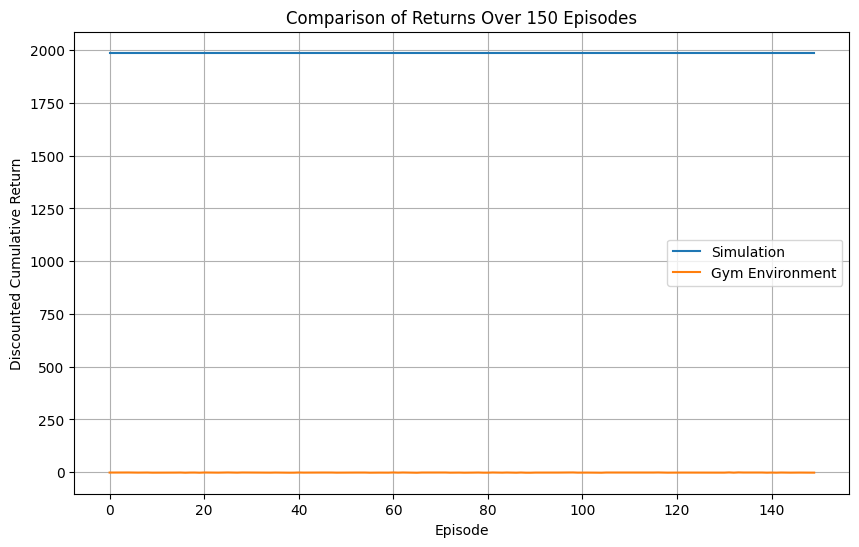

In [97]:
'''
def pi(s: int) -> int:
    return 0 if s <= 3 else 1  # Replace if state ≤ 3, else leave

def compare_sim_trajectory(pi, S, theta, C, gamma, max_steps=100):
    _, _, _, discounted_cost = trajectory(pi, S, theta, C, gamma, max_steps)
    traj_return = -discounted_cost  # Return scalar
    return traj_return

def gym_episode(env, pi, gamma, max_steps=100):
    obs = env.reset()
    traj_return = 0.0
    for t in range(max_steps):
        state = obs[0] + 1  # Convert 0-based → 1-based
        action = pi(state)
        obs, reward, done, _ = env.step(action)
        traj_return += (gamma ** t) * reward
        if done:
            break
    return traj_return

# Parameters
S = 100
theta = 0.5
C = 100
gamma = 0.95
n_episodes = 150

# Initialize
sim_returns = []
gym_returns = []

env = Machine_env(S=S, θ=theta, C=C, max_iter=100)

for _ in range(n_episodes):
    # Simulation return
    sim_return = compare_sim_trajectory(pi, S, theta, C, gamma)
    sim_returns.append(sim_return)

    # Gym return
    gym_return = gym_episode(env, pi, gamma)
    gym_returns.append(gym_return)

# Compare results
print(f"Simulation Average Return: {np.mean(sim_returns):.2f}")
print(f"Gym Environment Average Return: {np.mean(gym_returns):.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_returns, label="Simulation")
plt.plot(gym_returns, label="Gym Environment")
plt.xlabel("Episode")
plt.ylabel("Discounted Cumulative Return")
plt.title("Comparison of Returns Over 150 Episodes")
plt.legend()
plt.grid(True)
plt.show()

'''

**8)** For this lab, you will need to extend the code in this notebook to a more realistic set-up:

1.   **Test the DQN on the machine replacement problem** The code below implements a standard DQN algorithm. Once your environment is working execute the different cells below to run the DQN algorithm. Optimize the different hyperparameters and try to obtain the same strategy as the optimal one.

2.   **Extend the machine environment to a more complex and realistic set-up.** For instance, you can imagine that you have different qualities of reparations that will bring the machine in different states. The better the reparation is, the costlier it will be. Another possibility would be to assume that you have a finite number of machines and you can only do one replacement every two or three time-steps. You can propose other solutions.

*Note: you will have to explain well your environment (the state, the transition probability and the cost function). You will have to justify why the scenario chosen is interesting.*

3. **Pseudo code of the algorithm** The algorithm coded in this lab is not the standard DQN. The loss used is different and use the concept [Double DQN learning (see section 4.4)](https://arxiv.org/pdf/1811.12560). Write the pseudo code of the algorithm coded in this lab. You can get inspired from the pseudo code seen in class for the Q-learning algorithm and the Deep Q-learning alorightm.

4.   **Extend the DQN algorithm to your set-up.** You will need to run a DQN algorithm to your set-up. Most likely, you will have, at least, to change the dimension of the inputs and the dimension of the outputs of your NN. You will have to evaluate your DQN Algorithm and illustrate its performances.



### Training a DQN Algorithm<a class="anchor" id="3"></a>




This code has been inspired by https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

#### Required packages

In [26]:
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# start the env
S_max = 100
env = Machine_env(S_max,0.5,1)

#### Replay Memory

We'll be using experience replay memory for training our DQN. It stores
the transitions that the agent observes, allowing us to reuse this data
later. By sampling from it randomly, the transitions that build up a
batch are decorrelated. It has been shown that this greatly stabilizes
and improves the DQN training procedure.

For this, we're going to need two classses:

-  ``Transition`` - a named tuple representing a single transition in
   our environment. It essentially maps (state, action) pairs
   to their (next_state, reward) result, with the state being the
   screen difference image as described later on.
-  ``ReplayMemory`` - a cyclic buffer of bounded size that holds the
   transitions observed recently. It also implements a ``.sample()``
   method for selecting a random batch of transitions for training.


In [27]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

Now, let's define our model. But first, let's quickly recap what a DQN is.

#### DQN algorithm

Our aim will be to train a policy that tries to maximize the discounted,
cumulative reward
$R_{t_0} = \sum_{t=t_0}^{\infty} \gamma^{t - t_0} r_t$, where
$R_{t_0}$ is also known as the *return*. The discount,
$\gamma$, should be a constant between $0$ and $1$
that ensures the sum converges. A lower $\gamma$ makes
rewards from the uncertain far future less important for our agent
than the ones in the near future that it can be fairly confident
about. It also encourages agents to collect reward closer in time
than equivalent rewards that are temporally far away in the future.

The main idea behind Q-learning is that if we had a function
$Q^*: State \times Action \rightarrow \mathbb{R}$, that could tell
us what our return would be, if we were to take an action in a given
state, then we could easily construct a policy that maximizes our
rewards:

\begin{align}\pi^*(s) = \arg\!\max_a \ Q^*(s, a)\end{align}

However, we don't know everything about the world, so we don't have
access to $Q^*$. But, since neural networks are universal function
approximators, we can simply create one and train it to resemble
$Q^*$.

For our training update rule, we'll use a fact that every $Q$
function for some policy obeys the Bellman equation:

\begin{align}Q^{\pi}(s, a) = r + \gamma Q^{\pi}(s', \pi(s'))\end{align}

The difference between the two sides of the equality is known as the
temporal difference error, $\delta$:

\begin{align}\delta = Q(s, a) - (r + \gamma \max_a' Q(s', a))\end{align}

To minimise this error, we will use the [Huber
loss](https://en.wikipedia.org/wiki/Huber_loss)_. The Huber loss acts
like the mean squared error when the error is small, but like the mean
absolute error when the error is large - this makes it more robust to
outliers when the estimates of $Q$ are very noisy. We calculate
this over a batch of transitions, $B$, sampled from the replay
memory:

\begin{align}\mathcal{L} = \frac{1}{|B|}\sum_{(s, a, s', r) \ \in \ B} \mathcal{L}(\delta)\end{align}

\begin{align}\text{where} \quad \mathcal{L}(\delta) = \begin{cases}
     \frac{1}{2}{\delta^2}  & \text{for } |\delta| \le 1, \\
     |\delta| - \frac{1}{2} & \text{otherwise.}
   \end{cases}\end{align}

#### Q-network

Our model will be a feed forward  neural network that takes in the
difference between the current and previous screen patches. It has two
outputs, representing $Q(s, \mathrm{left})$ and
$Q(s, \mathrm{right})$ (where $s$ is the input to the
network). In effect, the network is trying to predict the *expected return* of
taking each action given the current input.




In [107]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [48]:
# gretaer layer sizes
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256,256)
        self.layer3 = nn.Linear(256, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [44]:
# Dropout alternative DQN model
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.dropout1 = nn.Dropout(p=0.2)  # 20% dropout
        self.layer2 = nn.Linear(128, 128)
        self.dropout2 = nn.Dropout(p=0.2)
        self.output = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        return self.output(x)


In [40]:
# self atention alternative DQN
class DQNWithAttention(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.fc = nn.Linear(n_observations, 128)
        self.attn = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)
        self.out = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.fc(x))  # shape: (batch, seq_len, 128)
        attn_output, _ = self.attn(x, x, x)  # self-attention
        return self.out(attn_output.mean(dim=1))  # average over sequence


#### Training

**Hyperparameters and utilities**
This cell instantiates our model and its optimizer, and defines some
utilities:

-  ``select_action`` - will select an action accordingly to an epsilon
   greedy policy. Simply put, we'll sometimes use our model for choosing
   the action, and sometimes we'll just sample one uniformly. The
   probability of choosing a random action will start at ``EPS_START``
   and will decay exponentially towards ``EPS_END``. ``EPS_DECAY``
   controls the rate of the decay.
-  ``plot_durations`` - a helper for plotting the durations of episodes,
   along with an average over the last 100 episodes (the measure used in
   the official evaluations). The plot will be underneath the cell
   containing the main training loop, and will update after every
   episode.

In [112]:
# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the AdamW optimizer
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000
TAU = 1e-3  # 0.005 originally
LR = 1e-4

# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state = env.reset()
n_observations = 1 # env.observation_space.n  # 1 originally

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict()) #? copies the weights and biases from policy_net to target_net

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)


steps_done = 0


def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            # print("Policy greedy: ", policy_net(state))
            # print("Policy greedy :" , policy_net(state).argmax().view(1,1) )
            #return torch.argmax(policy_net(state))
            return policy_net(state).argmax().view(1,1)
            # return policy_net(state).argmax(dim=1).view(1, 1)


    else:
      random_action = env.action_space.sample()
    #   print("Random action: ", random_action)
      return torch.tensor([[random_action]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

def plot_trajectory_returns(trajectory_returns, show_result=False):
    plt.figure(1)
    trajectory_returns_t = torch.tensor(trajectory_returns, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Training Episodes')
    plt.ylabel('Trajectory Return')
    plt.plot(trajectory_returns_t.numpy())
    # Take 100 episode averages and plot them too
    # if len(trajectory_returns_t) >= 100:
    #     means = trajectory_returns_t.unfold(0, 100, 1).mean(1).view(-1)
    #     means = torch.cat((torch.zeros(99), means))
    #     plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())



#### Training loop

Finally, the code for training our model.

Here, you can find an ``optimize_model`` function that performs a
single step of the optimization. It first samples a batch, concatenates
all the tensors into a single one, computes $Q(s_t, a_t)$ and
$V(s_{t+1}) = \max_a Q(s_{t+1}, a)$, and combines them into our
loss. By definition we set $V(s) = 0$ if $s$ is a terminal
state. We also use a target network to compute $V(s_{t+1})$ for
added stability. The target network is updated at every step with a
[soft update](https://arxiv.org/pdf/1509.02971.pdf)_ controlled by
the hyperparameter ``TAU``, which was previously defined.




In [113]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    # print(batch.action)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1)[0].
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

In [73]:
def to_onehot(state, n_observations):
    onehot = torch.zeros(1, n_observations, dtype=torch.float32, device=device)
    onehot[0, state] = 1.0
    return onehot

Below, you can find the main training loop. At the beginning we reset
the environment and obtain the initial ``state`` Tensor. Then, we sample
an action, execute it, observe the next state and the reward (always
1), and optimize our model once. When the episode ends (our model
fails), we restart the loop.

Below, `num_episodes` is set to 600 if a GPU is available, otherwise 50
episodes are scheduled so training does not take too long. However, 50
episodes is insufficient for to observe good performance on cartpole.
You should see the model constantly achieve 500 steps within 600 training
episodes. Training RL agents can be a noisy process, so restarting training
can produce better results if convergence is not observed.



In [111]:
torch.cuda.is_available() # False

False

Complete


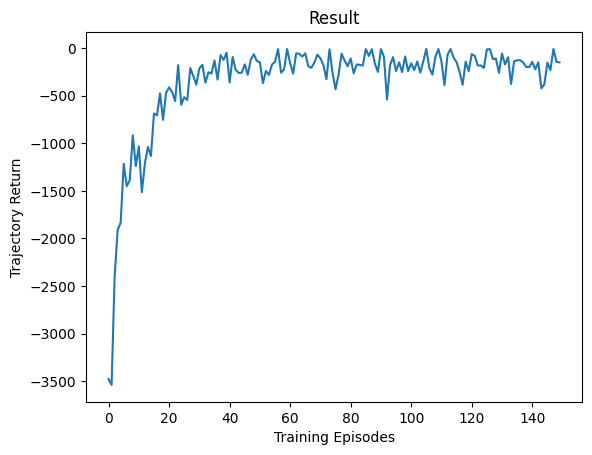

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [114]:
if torch.cuda.is_available():
    num_episodes = 600
else:
    num_episodes = 150 # 1000

trajectory_returns = []

for i_episode in range(num_episodes):
    # Initialize the environment and get it's state
    state = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    # state = to_onehot(state, n_observations)  # shape: (1, 100)
    traj_return = 0
    for t in count():
        # print("State : ", state)
        action = select_action(state)
        observation, reward, terminated, info = env.step(action.item())    # or truncated by max_iterations is an option available in other gym env versions
        traj_return = traj_return + (GAMMA ** t ) * reward
        reward = torch.tensor([reward], device=device)
        done = terminated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            # episode_durations.append(t + 1)
            # plot_durations()
            trajectory_returns.append(traj_return)
            plot_trajectory_returns(trajectory_returns)
            break

print('Complete')
# plot_durations(show_result=True)
plot_trajectory_returns(trajectory_returns, show_result=True)
plt.ioff()
plt.show()





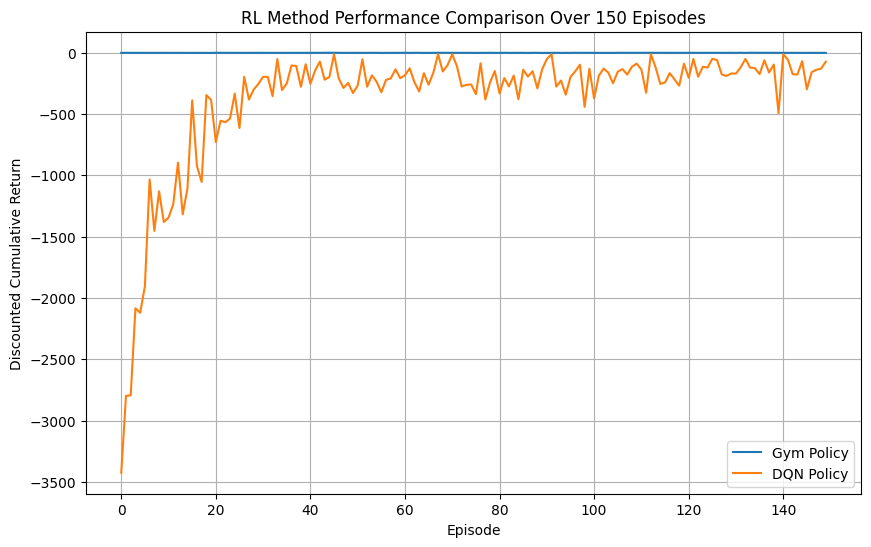

In [106]:
# Plot all three
dqn_returns = trajectory_returns
plt.figure(figsize=(10, 6))
# plt.plot(sim_returns, label="Simulation Policy")
plt.plot(gym_returns, label="Gym (no DQN) Method")
plt.plot(dqn_returns, label="DQN Method")
plt.xlabel("Episode")
plt.ylabel("Discounted Cumulative Return")
plt.title("RL Method Performance Comparison Over 150 Episodes")
plt.legend()
plt.grid(True)
plt.show()

In [105]:
# inputs_test = torch.tensor([float(i) for i in range(99)])
# print(inputs_test)
# for i in range(99):
#   print(policy_net(torch.tensor(inputs_test[i]))[0])

for i in range(99):
  Q = policy_net(torch.tensor([float(i)]))
  print(Q[0]-Q[1])

tensor(-0.3340, grad_fn=<SubBackward0>)
tensor(-0.8931, grad_fn=<SubBackward0>)
tensor(-1.8833, grad_fn=<SubBackward0>)
tensor(-2.9568, grad_fn=<SubBackward0>)
tensor(-4.0586, grad_fn=<SubBackward0>)
tensor(-5.1676, grad_fn=<SubBackward0>)
tensor(-6.2759, grad_fn=<SubBackward0>)
tensor(-7.3849, grad_fn=<SubBackward0>)
tensor(-8.4940, grad_fn=<SubBackward0>)
tensor(-9.5994, grad_fn=<SubBackward0>)
tensor(-10.7030, grad_fn=<SubBackward0>)
tensor(-11.8036, grad_fn=<SubBackward0>)
tensor(-12.9008, grad_fn=<SubBackward0>)
tensor(-13.9980, grad_fn=<SubBackward0>)
tensor(-15.0950, grad_fn=<SubBackward0>)
tensor(-16.1924, grad_fn=<SubBackward0>)
tensor(-17.2905, grad_fn=<SubBackward0>)
tensor(-18.3884, grad_fn=<SubBackward0>)
tensor(-19.4851, grad_fn=<SubBackward0>)
tensor(-20.5817, grad_fn=<SubBackward0>)
tensor(-21.6783, grad_fn=<SubBackward0>)
tensor(-22.7756, grad_fn=<SubBackward0>)
tensor(-23.8730, grad_fn=<SubBackward0>)
tensor(-24.9694, grad_fn=<SubBackward0>)
tensor(-26.0657, grad_fn=<

Documentation OpenAI Gym : https://www.gymlibrary.dev/content/basic_usage/

Part of this lab has been prepared by Pierre Charreaux, Théo Tembou Nzudie during their Project 3A.